# C4 Paper 2 — Reliability under Prior Shift (Complete)

**Paper 2 Extension — original C4 protocol fully preserved.**

Notebook này giữ nguyên toàn bộ seed, dataset, pipeline và training logic của C4 gốc.
RF + XGBoost được tích hợp vào pipeline theo đúng checklist Paper 2.

| Contribution | Metrics | Deliverables |
|---|---|---|
| C3 Reliability under Prior Shift | ECE, Brier Score, AUC-PR | Figure 5, Table IV |
| A2 Temporal Reliability | ECE, Brier temporal | Discussion / Appendix |

**Scope:**

| Included | Excluded |
|---|---|
| Prior shift: Balanced / Attack-heavy / DoS-only | Gaussian perturbation (Paper 1 only) |
| ECE, Brier, AUC-PR as primary metrics | F1 robustness narrative |
| Reliability diagrams | Margin stability as main result |
| Temporal reliability (supplementary) | Kernel geometry / KTA |
| Cohen's d effect sizes | E2 feature perturbation |
| Random Forest + XGBoost baselines | U2R/R2L terminology |

**Protocol:** RANDOM_STATE=42, RUN_IDS=[1,2,3,4,5], same seed as C4 original.
Models are loaded from C4 original cache when available (avoids retraining QSVM).


## 0. Imports & Paper 2 Dependencies

In [33]:
import math
import os
import time
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import display

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False
    XGBClassifier = None
    print('[WARN] xgboost not available; HistGradientBoosting fallback will be used.')
    print('       pip install xgboost  to use the intended baseline.')

from qiskit.circuit.library import zz_feature_map
from qiskit_machine_learning.kernels import FidelityStatevectorKernel

warnings.filterwarnings('ignore')

import qiskit, qiskit_machine_learning

print(f'Qiskit                  : {qiskit.__version__}')
print(f'Qiskit Machine Learning : {qiskit_machine_learning.__version__}')
print(f'XGBoost available       : {HAS_XGBOOST}')
print(f'Backend                 : FidelityStatevectorKernel (statevector, noiseless)')


Qiskit                  : 2.3.0
Qiskit Machine Learning : 0.9.0
XGBoost available       : True
Backend                 : FidelityStatevectorKernel (statevector, noiseless)


## 1. Configuration

All hyperparameters and flags defined here

In [34]:
# ─── Reproducibility — MUST match C4 original ────────────────────────────────
RANDOM_STATE = 42
RUN_IDS      = [1, 2, 3, 4, 5]
np.random.seed(RANDOM_STATE)

# ─── Path resolution ─────────────────────────────────────────────────────────
def resolve_root_dir():
    cwd = Path(os.getcwd()).resolve()
    for base in [cwd, *cwd.parents]:
        if (base / 'data' / 'processed_data').exists() or (base / 'models').exists():
            return base
    return cwd

ROOT_DIR   = resolve_root_dir()
DATA_DIR   = ROOT_DIR / 'data' / 'processed_data'
MODELS_DIR = ROOT_DIR / 'models'
OUTPUT_DIR = ROOT_DIR / 'results' / 'c4_paper2'
FIG_DIR    = OUTPUT_DIR / 'figures'
CACHE_DIR  = OUTPUT_DIR / 'cache'
for d in [OUTPUT_DIR, FIG_DIR, CACHE_DIR]:
    Path(d).mkdir(parents=True, exist_ok=True)

# ─── QSVM hyperparameters — MUST match C4 original ───────────────────────────
N_QUBITS     = 4
ANGLE_MAX    = np.pi
REPS         = 2
ENTANGLEMENT = 'full'
C_QSVM       = 1.0
TRAIN_SIZE   = 1000
LABEL_COLS   = ['label', 'label_binary', 'label_multiclass', 'attack_category']

# ─── SVM-RBF C from C4 original ──────────────────────────────────────────────
# C4 gốc: SVM-RBF (std) dùng C=10.0; Paper 2 dùng SVM-RBF (std) làm baseline RBF chính.
C_RBF_STD = 10.0

# ─── Prior shift experiment settings ─────────────────────────────────────────
SHIFT_TEST_SIZE     = 300          # phải khớp với C4 gốc E3_N = 300
SHIFT_SEED          = RANDOM_STATE  # dùng cùng seed với C4 gốc E3_SEED = RANDOM_STATE + 300
                                    # (sẽ được tính lại bên dưới để đồng bộ chính xác)
N_CALIBRATION_BINS  = 15           # bins cho ECE
FORCE_REBUILD_CACHE     = True  # True → bỏ P2 model cache, retrain RF/XGB
USE_C4_ORIG_CACHE       = False   # False → bỏ C4 original cache, retrain QSVM + SVM-RBF
REBUILD_SHIFT_DATASETS  = True  # True → regenerate tất cả test sets từ đầu

# ─── C4 original cache path (Paper 2 reuses QSVM + SVM-RBF from C4 gốc) ─────
# C4 gốc lưu models tại: ../results/c4_multirun/cache/run_N/models_<CONFIG_TAG>_runN.joblib
# CONFIG_TAG của C4 gốc:
def _fmt_c_for_tag(c):
    return f'{float(c):g}'.replace('.', 'p')

SVM_MODEL_KEYS = [
    'SVM-Linear (mm)', 'SVM-Linear (std)',
    'SVM-Poly2 (mm)',  'SVM-Poly2 (std)',
    'SVM-RBF (mm)',    'SVM-RBF (std)',
]
SVM_C_VALUES = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 10.0], dtype=float)
SVM_C_BY_MODEL = dict(zip(SVM_MODEL_KEYS, SVM_C_VALUES))
SVM_C_TAG = '-'.join(
    f'{k.replace("SVM-","").replace(" ","").replace("(","").replace(")","").lower()}'
    f'{_fmt_c_for_tag(SVM_C_BY_MODEL[k])}'
    for k in SVM_MODEL_KEYS
)
C4_ORIG_CONFIG_TAG = f'reps{REPS}_{ENTANGLEMENT}_C{C_QSVM}_cs{SVM_C_TAG}_n{TRAIN_SIZE}'

# Paper 2 CONFIG_TAG (includes RF/XGB)
CONFIG_TAG = (
    f'reps{REPS}_{ENTANGLEMENT}_cq{C_QSVM:g}_crbf{C_RBF_STD:g}'
    f'_n{TRAIN_SIZE}_shift{SHIFT_TEST_SIZE}_p2'
)

# ─── Paper 2 Model order (4 models only) ─────────────────────────────────────
MODEL_ORDER = ['QSVM (ZZ)', 'SVM-RBF', 'Random Forest', 'XGBoost']

PLOT_COLORS = {
    'QSVM (ZZ)'    : '#1f77b4',
    'SVM-RBF'      : '#ff7f0e',
    'Random Forest': '#2ca02c',
    'XGBoost'      : '#d62728',
}
MARKERS = {
    'QSVM (ZZ)'    : 'o',
    'SVM-RBF'      : 's',
    'Random Forest': '^',
    'XGBoost'      : 'D',
}
LINESTYLES = {
    'QSVM (ZZ)'    : '-',
    'SVM-RBF'      : '--',
    'Random Forest': '-.',
    'XGBoost'      : ':',
}

DIST_ORDER  = ['Balanced', 'Attack-heavy', 'DoS-only']
USE_TEMPORAL_ANALYSIS = True   # set False để skip KDDTest-21

print(f'ROOT_DIR   : {ROOT_DIR}')
print(f'OUTPUT_DIR : {OUTPUT_DIR}')
print(f'C4_ORIG_CONFIG_TAG : {C4_ORIG_CONFIG_TAG}')
print(f'CONFIG_TAG (P2)    : {CONFIG_TAG}')
print(f'RUN_IDS    : {RUN_IDS}')


ROOT_DIR   : D:\coding\Research\Quantum\SVM
OUTPUT_DIR : D:\coding\Research\Quantum\SVM\results\c4_paper2
C4_ORIG_CONFIG_TAG : reps2_full_C1.0_cslinearmm0p1-linearstd0p1-poly2mm0p1-poly2std0p1-rbfmm0p1-rbfstd10_n1000
CONFIG_TAG (P2)    : reps2_full_cq1_crbf10_n1000_shift300_p2
RUN_IDS    : [1, 2, 3, 4, 5]


## 2. Load Zero-Leakage Pipeline Transformers

In [35]:
selector = joblib.load(MODELS_DIR / 'feature_selector_k20.joblib')
pca      = joblib.load(MODELS_DIR / 'pca_4components.joblib')
scaler   = joblib.load(MODELS_DIR / 'scaler_minmax_pi.joblib')

print(f'SelectKBest k     : {selector.k}')
print(f'PCA components    : {pca.n_components_}')
print(f'PCA explained var : {pca.explained_variance_ratio_.sum()*100:.2f}%')
PC_LABELS = [f'PC{i+1}' for i in range(N_QUBITS)]


def infer_feature_cols(df: pd.DataFrame):
    return [c for c in df.columns if c not in LABEL_COLS]


def transform_pipeline(df: pd.DataFrame, feature_cols):
    """Raw → SelectKBest → PCA → MinMaxScaler [0, π]. For QSVM."""
    X_raw = df[feature_cols].to_numpy(dtype=np.float32)
    X_sel = selector.transform(X_raw)
    X_pca = pca.transform(X_sel)
    return np.clip(scaler.transform(X_pca), 0.0, ANGLE_MAX).astype(np.float64)


def pca_features(df: pd.DataFrame, feature_cols):
    """Raw → SelectKBest → PCA (before MinMax). For classical models."""
    X_raw = df[feature_cols].to_numpy(dtype=np.float32)
    X_sel = selector.transform(X_raw)
    return pca.transform(X_sel).astype(np.float64)


# Probe feature columns from train_run1
def find_train_path(run_id):
    for p in [
        DATA_DIR / 'multi_run' / f'train_run{run_id}.csv',
        DATA_DIR / f'train_run{run_id}.csv',
    ]:
        if p.exists():
            return p
    raise FileNotFoundError(f'Cannot find train_run{run_id}.csv under {DATA_DIR}')

probe_df     = pd.read_csv(find_train_path(1))
feature_cols = infer_feature_cols(probe_df)
assert len(probe_df) == TRAIN_SIZE, f'Expected TRAIN_SIZE={TRAIN_SIZE}, got {len(probe_df)}'
print(f'Feature columns : {len(feature_cols)}')


SelectKBest k     : 20
PCA components    : 4
PCA explained var : 86.62%
Feature columns : 122


## 3. Model Builders

Paper 2 baselines: QSVM-ZZ, SVM-RBF, Random Forest, XGBoost.

**Note:** QSVM và SVM-RBF sẽ được load từ cache C4 gốc nếu có, tránh retrain tốn thời gian.

In [36]:
def build_qsvm(C: float = C_QSVM, random_state: int = RANDOM_STATE):
    fm = zz_feature_map(
        feature_dimension=N_QUBITS,
        reps=REPS,
        entanglement=ENTANGLEMENT,
    )
    kernel = FidelityStatevectorKernel(
        feature_map=fm,
        shots=None,
        enforce_psd=True,
        cache_size=None,
    )
    return SVC(kernel=kernel.evaluate, C=C, probability=True, random_state=random_state)


def build_rbf_svm(C: float = C_RBF_STD, random_state: int = RANDOM_STATE):
    return SVC(kernel='rbf', C=C, probability=True, random_state=random_state)


def build_random_forest(random_state: int = RANDOM_STATE):
    return RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        class_weight='balanced_subsample',
        n_jobs=-1,
        random_state=random_state,
    )


def build_xgboost(random_state: int = RANDOM_STATE, scale_pos_weight: float = 1.0):
    if HAS_XGBOOST:
        return XGBClassifier(
            n_estimators=500,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            min_child_weight=1.0,
            objective='binary:logistic',
            eval_metric='logloss',
            tree_method='hist',
            scale_pos_weight=float(scale_pos_weight),
            random_state=random_state,
            n_jobs=-1,
        )
    # Fallback khi chưa cài xgboost
    print('[FALLBACK] Using HistGradientBoostingClassifier (XGBoost not installed)')
    return HistGradientBoostingClassifier(
        max_depth=6,
        learning_rate=0.05,
        max_iter=300,
        random_state=random_state,
    )


def predict_positive_proba(model, X):
    """Return P(y=1) in a model-agnostic way."""
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X)
        if proba.ndim == 2 and proba.shape[1] >= 2:
            return proba[:, 1].astype(np.float64)
        return proba.ravel().astype(np.float64)
    # SVC fallback (probability=True should always be set)
    score = np.asarray(model.decision_function(X), dtype=float)
    return (1.0 / (1.0 + np.exp(-score)))


print('Model builders ready.')


Model builders ready.


## 4. Sampling Helpers

Giống hệt C4 gốc — rare-first allocation, exact n_samples, cache-backed sets.

In [37]:
# ─── Exact count allocator (same as C4 original / preprocess.ipynb) ──────────
def _allocate_exact_counts(categories, counts, total, ensure_min_one=True):
    categories = list(categories)
    counts = pd.Series(counts, index=categories, dtype=float)
    targets = pd.Series(0, index=categories, dtype=int)

    if total <= 0 or len(categories) == 0:
        return targets.to_dict()

    positive = counts[counts > 0]
    if positive.empty:
        return targets.to_dict()

    cats = list(positive.index)
    total = int(total)

    if ensure_min_one and total >= len(cats):
        targets.loc[cats] = 1
        remaining = total - len(cats)
    else:
        remaining = total

    if remaining > 0:
        weights = positive / positive.sum()
        raw = weights * remaining
        floors = np.floor(raw).astype(int)
        targets.loc[cats] += floors

        deficit = total - int(targets.sum())
        if deficit > 0:
            remainders = (raw - floors).sort_values(ascending=False)
            for cat in remainders.index[:deficit]:
                targets.loc[cat] += 1

    return targets.to_dict()


def _split_exact_counts(total, proportions):
    """Split integer total into exact integer counts using largest remainder."""
    props = np.asarray(proportions, dtype=float) / sum(proportions)
    raw = props * int(total)
    base = np.floor(raw).astype(int)
    deficit = int(total) - int(base.sum())
    if deficit > 0:
        remainders = raw - base
        order = np.argsort(-remainders)
        for idx in order[:deficit]:
            base[idx] += 1
    return base.astype(int)


def stratified_sample_for_qsvm(
    df,
    n_samples=1000,
    min_rare=30,
    rare_categories=('U2R', 'R2L'),
    random_state=42,
):
    """Mirror preprocess.ipynb: rare categories first, exact n_samples, final guard."""
    if n_samples <= 0:
        raise ValueError('n_samples must be positive')
    if len(df) == 0:
        raise ValueError('Cannot sample from an empty DataFrame')

    rng = np.random.RandomState(random_state)
    sampled = []

    all_cats = list(df['attack_category'].dropna().unique())
    rare_cats  = [c for c in rare_categories if c in all_cats]
    other_cats = [c for c in all_cats if c not in rare_cats]

    rare_targets = {}
    if rare_cats:
        rare_budget = min(n_samples, int(min_rare) * len(rare_cats))
        rare_counts = df['attack_category'].value_counts().reindex(rare_cats).fillna(0)
        rare_targets = _allocate_exact_counts(
            rare_cats, rare_counts, rare_budget, ensure_min_one=True,
        )

    used = 0
    for cat, n_take in rare_targets.items():
        if n_take <= 0:
            continue
        pool = df[df['attack_category'] == cat]
        sampled.append(pool.sample(n=n_take, replace=len(pool) < n_take,
                                   random_state=rng.randint(1_000_000)))
        used += n_take

    remaining = n_samples - used
    if remaining > 0:
        if other_cats:
            other_counts = df['attack_category'].value_counts().reindex(other_cats).fillna(0)
            other_targets = _allocate_exact_counts(
                other_cats, other_counts, remaining, ensure_min_one=True,
            )
        else:
            other_targets = {}

        for cat, n_take in other_targets.items():
            if n_take <= 0:
                continue
            pool = df[df['attack_category'] == cat]
            sampled.append(pool.sample(n=n_take, replace=len(pool) < n_take,
                                       random_state=rng.randint(1_000_000)))
            used += n_take

    result = pd.concat(sampled) if sampled else df.iloc[0:0].copy()

    if len(result) < n_samples:
        need = n_samples - len(result)
        selected_idx = pd.Index(result.index).unique()
        available = df.drop(index=selected_idx, errors='ignore')
        if len(available) >= need:
            extra = available.sample(n=need, replace=False, random_state=rng.randint(1_000_000))
        else:
            extra = df.sample(n=need, replace=True, random_state=rng.randint(1_000_000))
        result = pd.concat([result, extra])
    elif len(result) > n_samples:
        result = result.sample(n=n_samples, replace=False, random_state=rng.randint(1_000_000))

    result = result.sample(frac=1, random_state=random_state).reset_index(drop=True)
    assert len(result) == n_samples, f'Expected {n_samples}, got {len(result)}'
    return result


def sample_attack_category_exact(df, category_counts, random_state=42):
    """Exact sample by attack_category counts."""
    rng = np.random.RandomState(random_state)
    parts = []
    for cat, n_take in category_counts.items():
        pool = df[df['attack_category'] == cat]
        if len(pool) == 0:
            raise ValueError(f'Missing attack_category={cat} for exact sampling')
        parts.append(pool.sample(n=int(n_take), replace=len(pool) < int(n_take),
                                 random_state=rng.randint(1_000_000)))
    result = pd.concat(parts).sample(frac=1, random_state=random_state).reset_index(drop=True)
    assert len(result) == sum(category_counts.values())
    return result


def _load_or_build_exact(path, builder_fn, expected_n, name):
    if os.path.exists(path) and not REBUILD_SHIFT_DATASETS and not FORCE_REBUILD_CACHE:
        df = pd.read_csv(path)
        if len(df) == expected_n:
            return df
        print(f'[REBUILD] {name}: cached size={len(df)} != expected={expected_n}')
    elif os.path.exists(path) and (REBUILD_SHIFT_DATASETS or FORCE_REBUILD_CACHE):
        print(f'[REBUILD] {name}: forced rebuild')
    df = builder_fn()
    assert len(df) == expected_n, f'{name}: expected {expected_n}, got {len(df)}'
    try:
        df.to_csv(path, index=False)
    except PermissionError:
        stem, ext = os.path.splitext(path)
        alt_path = f'{stem}_exact{ext}'
        df.to_csv(alt_path, index=False)
        print(f'[WARN] Cannot overwrite: {path}')
        print(f'[SAVED] {alt_path}')
    return df


print('Sampling helpers ready.')


Sampling helpers ready.


## 5. Build Fixed Evaluation Sets

Test sets được build/cache theo seed:
- **E3 prior shift** (Balanced/Attack-heavy/DoS-only): dùng E3_SEED = RANDOM_STATE + 300 = 342
- **E1 temporal** (KDDTest+ / KDDTest-21): dùng E1_SEED = RANDOM_STATE + 300 = 342

Nếu cache C4 đã tồn tại (`NSL_KDD_Test_C4_E3*.csv`), load lại trực tiếp hoặc có thể recreate.

In [38]:
# ─── Load test pools ─────────────────────────────────────────────────────────
df_test_std = pd.read_csv(DATA_DIR / 'NSL_KDD_Test_Cleaned.csv')
test_21_path = DATA_DIR / 'NSL_KDD_Test21_Cleaned.csv'
df_test_21   = pd.read_csv(test_21_path) if test_21_path.exists() else None
if df_test_21 is None:
    print('[WARN] KDDTest-21 not found; temporal analysis will be skipped.')
    USE_TEMPORAL_ANALYSIS = False

print(f'KDDTest+   (standard) : {df_test_std.shape}')
print(f'KDDTest-21 (hard)     : {df_test_21.shape if df_test_21 is not None else "N/A"}')

# ─── E3 Prior shift sets ──────────────────────────────────────────────────────
E3_N        = SHIFT_TEST_SIZE
E3_MIN_RARE = max(5, E3_N // 20)
E3_SEED     = RANDOM_STATE + E3_N  # = 342

df_test_all = df_test_std.copy()
df_normal   = df_test_all[df_test_all['label_binary'] == 0]
df_attack   = df_test_all[df_test_all['label_binary'] == 1]

e3a_path_orig = DATA_DIR / f'NSL_KDD_Test_C4_E3a_Balanced_Sample{E3_N}.csv'
e3b_path_orig = DATA_DIR / f'NSL_KDD_Test_C4_E3b_AttackHeavy_Sample{E3_N}.csv'
e3c_path_orig = DATA_DIR / f'NSL_KDD_Test_C4_E3c_DoSOnly_Sample{E3_N}.csv'

e3a_path_p2 = CACHE_DIR / f'shift_e3a_balanced_{E3_N}.csv'
e3b_path_p2 = CACHE_DIR / f'shift_e3b_attackheavy_{E3_N}.csv'
e3c_path_p2 = CACHE_DIR / f'shift_e3c_dosonly_{E3_N}.csv'

def _pick_cache_or_p2(orig, p2):
    if USE_C4_ORIG_CACHE and not REBUILD_SHIFT_DATASETS and orig.exists():
        df = pd.read_csv(orig)
        if len(df) == E3_N:
            print(f'  [CACHE] Using C4 original: {orig.name}')
            return str(orig)
        print(f'  [WARN] C4 original size mismatch ({len(df)} != {E3_N}), falling back.')
    elif not USE_C4_ORIG_CACHE:
        print(f'  [SKIP] USE_C4_ORIG_CACHE=False: {orig.name}')
    elif REBUILD_SHIFT_DATASETS:
        print(f'  [REBUILD] REBUILD_SHIFT_DATASETS=True: {orig.name}')
    if not REBUILD_SHIFT_DATASETS and p2.exists():
        print(f'  [CACHE] Using P2 cache: {p2.name}')
        return str(p2)
    print(f'  [BUILD] Will regenerate: {p2.name}')
    return str(p2)

e3a_path = _pick_cache_or_p2(e3a_path_orig, e3a_path_p2)
e3b_path = _pick_cache_or_p2(e3b_path_orig, e3b_path_p2)
e3c_path = _pick_cache_or_p2(e3c_path_orig, e3c_path_p2)


def build_e3a():
    n_nrm = E3_N // 2
    n_atk = E3_N - n_nrm
    normal_part = df_normal.sample(n=n_nrm, replace=len(df_normal) < n_nrm,
                                   random_state=E3_SEED)
    attack_part = stratified_sample_for_qsvm(df_attack, n_atk, E3_MIN_RARE,
                                             random_state=E3_SEED)
    result = pd.concat([normal_part, attack_part]).sample(
        frac=1, random_state=E3_SEED).reset_index(drop=True)
    assert len(result) == E3_N
    return result


def build_e3b():
    n_atk = int(round(E3_N * 0.7))
    n_nrm = E3_N - n_atk
    normal_part = df_normal.sample(n=n_nrm, replace=len(df_normal) < n_nrm,
                                   random_state=E3_SEED + 1)
    attack_part = stratified_sample_for_qsvm(df_attack, n_atk, E3_MIN_RARE,
                                             random_state=E3_SEED + 1)
    result = pd.concat([normal_part, attack_part]).sample(
        frac=1, random_state=E3_SEED).reset_index(drop=True)
    assert len(result) == E3_N
    return result


def build_e3c():
    return sample_attack_category_exact(
        df_test_all,
        {'DoS': E3_N // 2, 'Normal': E3_N - E3_N // 2},
        random_state=E3_SEED + 2,
    )


df_e3a = _load_or_build_exact(e3a_path, build_e3a, E3_N, 'E3 Balanced')
df_e3b = _load_or_build_exact(e3b_path, build_e3b, E3_N, 'E3 Attack-heavy')
df_e3c = _load_or_build_exact(e3c_path, build_e3c, E3_N, 'E3 DoS-only')

shift_sets = {
    'Balanced'    : df_e3a,
    'Attack-heavy': df_e3b,
    'DoS-only'    : df_e3c,
}

print(f'\nPrior-shift sets (E3_SEED={E3_SEED}):')
for name, df_s in shift_sets.items():
    vc  = df_s['label_binary'].value_counts()
    pct = vc / len(df_s) * 100
    print(f'  {name:15s}: n={len(df_s)}  '
          f'Normal={pct.get(0,0):.1f}%  Attack={pct.get(1,0):.1f}%')

# ─── E1 Temporal sets ─────────────────────────────────────────────────────────
E1_N        = 300
E1_MIN_RARE = max(5, E1_N // 20)
E1_SEED     = RANDOM_STATE + E1_N  # = 342

e1_std_path_orig = DATA_DIR / f'NSL_KDD_Test_C4_E1_Std_Sample{E1_N}.csv'
e1_21_path_orig  = DATA_DIR / f'NSL_KDD_Test_C4_E1_Hard_Sample{E1_N}.csv'

def _pick_e1_cache(orig, fallback_name):
    if USE_C4_ORIG_CACHE and not REBUILD_SHIFT_DATASETS and orig.exists():
        print(f'  [CACHE] Using C4 original: {orig.name}')
        return str(orig)
    elif not USE_C4_ORIG_CACHE:
        print(f'  [SKIP] USE_C4_ORIG_CACHE=False: {orig.name}')
    elif REBUILD_SHIFT_DATASETS:
        print(f'  [REBUILD] REBUILD_SHIFT_DATASETS=True: {orig.name}')
    return str(CACHE_DIR / fallback_name)

e1_std_path = _pick_e1_cache(e1_std_path_orig, f'e1_std_{E1_N}.csv')
e1_21_path  = _pick_e1_cache(e1_21_path_orig,  f'e1_21_{E1_N}.csv')

df_e1_std = _load_or_build_exact(
    e1_std_path,
    lambda: stratified_sample_for_qsvm(df_test_std, E1_N, E1_MIN_RARE, random_state=E1_SEED),
    E1_N, 'E1 KDDTest+'
)

if USE_TEMPORAL_ANALYSIS and df_test_21 is not None:
    df_e1_21 = _load_or_build_exact(
        e1_21_path,
        lambda: stratified_sample_for_qsvm(df_test_21, E1_N, E1_MIN_RARE, random_state=E1_SEED),
        E1_N, 'E1 KDDTest-21'
    )
    print(f'\nTemporal sets (E1_SEED={E1_SEED}):')
    print(f'  KDDTest+ : {len(df_e1_std)} samples')
    print(f'  KDDTest-21: {len(df_e1_21)} samples')
else:
    df_e1_21 = None
    USE_TEMPORAL_ANALYSIS = False
    print('\nTemporal analysis: SKIPPED')

print('\nAll evaluation sets ready.')

KDDTest+   (standard) : (22544, 126)
KDDTest-21 (hard)     : (11850, 126)
  [SKIP] USE_C4_ORIG_CACHE=False: NSL_KDD_Test_C4_E3a_Balanced_Sample300.csv
  [BUILD] Will regenerate: shift_e3a_balanced_300.csv
  [SKIP] USE_C4_ORIG_CACHE=False: NSL_KDD_Test_C4_E3b_AttackHeavy_Sample300.csv
  [BUILD] Will regenerate: shift_e3b_attackheavy_300.csv
  [SKIP] USE_C4_ORIG_CACHE=False: NSL_KDD_Test_C4_E3c_DoSOnly_Sample300.csv
  [BUILD] Will regenerate: shift_e3c_dosonly_300.csv

Prior-shift sets (E3_SEED=342):
  Balanced       : n=300  Normal=50.0%  Attack=50.0%
  Attack-heavy   : n=300  Normal=30.0%  Attack=70.0%
  DoS-only       : n=300  Normal=50.0%  Attack=50.0%
  [SKIP] USE_C4_ORIG_CACHE=False: NSL_KDD_Test_C4_E1_Std_Sample300.csv
  [SKIP] USE_C4_ORIG_CACHE=False: NSL_KDD_Test_C4_E1_Hard_Sample300.csv

Temporal sets (E1_SEED=342):
  KDDTest+ : 300 samples
  KDDTest-21: 300 samples

All evaluation sets ready.


## 6. Calibration & Evaluation Utilities

All metric computations centralized here.

In [39]:
def compute_ece(y_true, y_prob, n_bins=15):
    """Expected Calibration Error using equal-width bins.
    Returns (ece_scalar, bin_detail_df)."""
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)
    bins   = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins[1:-1], right=True)

    total = len(y_true)
    ece   = 0.0
    rows  = []
    for b in range(n_bins):
        mask  = bin_ids == b
        count = int(mask.sum())
        if count == 0:
            rows.append(dict(bin=b, count=0, conf_mean=np.nan,
                             acc_mean=np.nan, gap=np.nan,
                             left=bins[b], right=bins[b+1]))
            continue
        conf = float(np.mean(y_prob[mask]))
        acc  = float(np.mean(y_true[mask]))
        gap  = abs(acc - conf)
        ece += (count / total) * gap
        rows.append(dict(bin=b, count=count, conf_mean=conf,
                         acc_mean=acc, gap=gap,
                         left=bins[b], right=bins[b+1]))
    return float(ece), pd.DataFrame(rows)


def compute_brier(y_true, y_prob):
    return float(brier_score_loss(np.asarray(y_true, int), np.asarray(y_prob, float)))


def compute_auc_pr(y_true, y_prob):
    y_true = np.asarray(y_true, int)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(average_precision_score(y_true, np.asarray(y_prob, float)))


def evaluate_model(model_name, model, X_q, X_pca, std_scaler, y_true,
                   run_id, distribution_name, n_bins=15):
    """Run inference and compute all Paper 2 metrics for one model."""
    # Feature routing:
    # QSVM → angle-encoded features X_q
    # SVM-RBF → std-scaled PCA features
    # RF, XGB → raw PCA features (no additional scaling)
    if model_name == 'QSVM (ZZ)':
        y_prob = predict_positive_proba(model, X_q)
    elif model_name == 'SVM-RBF':
        y_prob = predict_positive_proba(model, std_scaler.transform(X_pca))
    else:
        y_prob = predict_positive_proba(model, X_pca)

    y_pred = (y_prob >= 0.5).astype(int)
    ece, ece_df = compute_ece(y_true, y_prob, n_bins=n_bins)

    row = {
        'run_id'            : run_id,
        'distribution_name' : distribution_name,
        'model_name'        : model_name,
        'accuracy'          : accuracy_score(y_true, y_pred),
        'f1_macro'          : f1_score(y_true, y_pred, average='macro', zero_division=0),
        'precision_pos'     : precision_score(y_true, y_pred, zero_division=0),
        'recall_pos'        : recall_score(y_true, y_pred, zero_division=0),
        'ece'               : ece,
        'brier'             : compute_brier(y_true, y_prob),
        'auc_pr'            : compute_auc_pr(y_true, y_prob),
        'roc_auc'           : float(roc_auc_score(y_true, y_prob))
                              if len(np.unique(y_true)) > 1 else np.nan,
    }
    payload = {'y_true': y_true.copy(), 'y_prob': y_prob.copy(), 'ece_df': ece_df}
    return row, payload


def cohens_d(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    if len(a) < 2 or len(b) < 2:
        return np.nan
    s_pool = np.sqrt(((np.std(a, ddof=1)**2) + (np.std(b, ddof=1)**2)) / 2.0)
    return float((np.mean(a) - np.mean(b)) / (s_pool + 1e-12))


def interpret_cohens_d(d):
    if np.isnan(d): return 'NA'
    ad = abs(d)
    if ad < 0.2:  return 'negligible'
    if ad < 0.5:  return 'small'
    if ad < 0.8:  return 'medium'
    return 'large'


def fmt(mean_val, std_val, digits=4):
    if pd.isna(mean_val): return 'NA'
    if pd.isna(std_val):  return f'{mean_val:.{digits}f}'
    return f'{mean_val:.{digits}f} \u00b1 {std_val:.{digits}f}'


def display_table(df, caption, highlight_cols=None):
    styled = (
        df.style
        .hide(axis='index')
        .set_caption(caption)
        .set_table_styles([
            {'selector': 'caption',
             'props': [('caption-side','top'),('font-size','15px'),
                       ('font-weight','bold'),('text-align','left'),('padding','8px 0')]},
            {'selector': 'th',
             'props': [('background-color','#263238'),('color','white'),
                       ('font-weight','bold'),('text-align','center'),('padding','6px 10px')]},
            {'selector': 'td',
             'props': [('text-align','center'),('padding','5px 10px'),
                       ('border-bottom','1px solid #ECEFF1')]},
        ])
    )
    if highlight_cols:
        styled = styled.background_gradient(cmap='YlGnBu', subset=highlight_cols)
    display(styled)


print('Evaluation utilities ready.')


Evaluation utilities ready.


## 7. Build / Load Models per Run

**Cache strategy:**
1. Nếu có cache C4 gốc (`c4_multirun/cache/run_N/`): load QSVM + SVM-RBF từ đó.
2. Train RF + XGBoost mới (nhanh hơn nhiều so với QSVM).
3. Lưu 4 models vào Paper 2 cache để tránh retrain lần sau.

In [40]:
def build_and_train_models(train_df, run_id):
    """
    Load QSVM + SVM-RBF từ C4 original cache nếu có (và USE_C4_ORIG_CACHE=True),
    train RF + XGBoost từ đầu.
    Returns: (models_dict, std_scaler)
    """
    X_train_q   = transform_pipeline(train_df, feature_cols)
    X_train_pca = pca_features(train_df, feature_cols)
    y_train     = train_df['label_binary'].to_numpy(dtype=np.int64)
    std_scaler  = StandardScaler().fit(X_train_pca)
    X_train_std = std_scaler.transform(X_train_pca)

    pos = max(int((y_train == 1).sum()), 1)
    neg = max(int((y_train == 0).sum()), 1)
    scale_pos_w = neg / pos

    # ── Paper 2 cache ─────────────────────────────────────────────────────────
    p2_cache = CACHE_DIR / f'p2_models_{CONFIG_TAG}_run{run_id}.joblib'
    if p2_cache.exists() and not FORCE_REBUILD_CACHE:
        store = joblib.load(p2_cache)
        print(f'  [RUN {run_id}] P2 cache hit → {p2_cache.name}')
        return store['models'], store['std_scaler']

    models = {}

    # ── Try to load QSVM + SVM-RBF from C4 original cache ────────────────────
    c4_orig_path = (
        ROOT_DIR / 'results' / 'c4_multirun' / 'cache'
        / f'run_{run_id}' / f'models_{C4_ORIG_CONFIG_TAG}_run{run_id}.joblib'
    )
    qsvm_loaded = False
    svm_loaded  = False

    if USE_C4_ORIG_CACHE and c4_orig_path.exists():
        try:
            store_orig = joblib.load(c4_orig_path)
            orig_clfs  = store_orig.get('classifiers', {})
            if 'QSVM (ZZ)' in orig_clfs:
                models['QSVM (ZZ)'] = orig_clfs['QSVM (ZZ)']
                qsvm_loaded = True
                print(f'  [RUN {run_id}] QSVM loaded from C4 original cache')
            if 'SVM-RBF (std)' in orig_clfs:
                models['SVM-RBF'] = orig_clfs['SVM-RBF (std)']
                svm_loaded = True
                print(f'  [RUN {run_id}] SVM-RBF loaded from C4 original cache (SVM-RBF (std))')
            if 'std_scaler' in store_orig and svm_loaded:
                std_scaler = store_orig['std_scaler']
        except Exception as e:
            print(f'  [RUN {run_id}] C4 cache load failed: {e}')
    elif not USE_C4_ORIG_CACHE:
        print(f'  [RUN {run_id}] C4 original cache disabled (USE_C4_ORIG_CACHE=False) → retrain QSVM + SVM-RBF')
    elif not c4_orig_path.exists():
        print(f'  [RUN {run_id}] C4 original cache not found → retrain QSVM + SVM-RBF')

    t0 = time.time()

    if not qsvm_loaded:
        print(f'  [RUN {run_id}] Training QSVM (ZZ) ...')
        models['QSVM (ZZ)'] = build_qsvm(C=C_QSVM, random_state=RANDOM_STATE + run_id)
        models['QSVM (ZZ)'].fit(X_train_q, y_train)
        print(f'  [RUN {run_id}] QSVM done in {time.time()-t0:.1f}s')

    if not svm_loaded:
        print(f'  [RUN {run_id}] Training SVM-RBF ...')
        models['SVM-RBF'] = build_rbf_svm(C=C_RBF_STD, random_state=RANDOM_STATE + run_id)
        models['SVM-RBF'].fit(std_scaler.transform(X_train_pca), y_train)

    print(f'  [RUN {run_id}] Training Random Forest ...')
    models['Random Forest'] = build_random_forest(random_state=RANDOM_STATE + run_id)
    models['Random Forest'].fit(X_train_pca, y_train)

    print(f'  [RUN {run_id}] Training XGBoost ...')
    models['XGBoost'] = build_xgboost(random_state=RANDOM_STATE + run_id,
                                       scale_pos_weight=scale_pos_w)
    models['XGBoost'].fit(X_train_pca, y_train)

    print(f'  [RUN {run_id}] All models ready in {time.time()-t0:.1f}s total')

    # Save Paper 2 cache
    joblib.dump({'models': models, 'std_scaler': std_scaler}, p2_cache)
    print(f'  [RUN {run_id}] Saved to {p2_cache.name}')

    return models, std_scaler


print('build_and_train_models defined.')

build_and_train_models defined.


## 8. Execute 5 Independent Runs

Evaluate QSVM, SVM-RBF, RF, XGBoost trên tất cả prior-shift distributions và temporal splits.

In [41]:
# Storage
all_prior_rows    = []
all_temporal_rows = []

# Payload store for reliability diagrams
prior_payload    = {}
temporal_payload = {}

for run_id in RUN_IDS:
    train_path = find_train_path(run_id)
    print(f'\n══ RUN {run_id} ══  ({train_path.name})')

    train_df = pd.read_csv(train_path)
    assert len(train_df) == TRAIN_SIZE, (
        f'Run {run_id}: expected {TRAIN_SIZE} rows, got {len(train_df)}'
    )
    assert infer_feature_cols(train_df) == feature_cols, (
        f'Run {run_id}: feature columns differ from run 1'
    )

    models, std_scaler = build_and_train_models(train_df, run_id)

    # Recompute X_train_pca for consistent std_scaler reference
    X_train_pca = pca_features(train_df, feature_cols)

    # ── Prior shift evaluation ────────────────────────────────────────────────
    for dist_name in DIST_ORDER:
        df_eval = shift_sets[dist_name]
        X_q    = transform_pipeline(df_eval, feature_cols)
        X_pca  = pca_features(df_eval, feature_cols)
        y_true = df_eval['label_binary'].to_numpy(dtype=np.int64)

        for model_name, model in models.items():
            row, payload = evaluate_model(
                model_name, model, X_q, X_pca, std_scaler,
                y_true, run_id, dist_name, n_bins=N_CALIBRATION_BINS
            )
            all_prior_rows.append(row)
            prior_payload[(run_id, dist_name, model_name)] = payload

    # ── Temporal reliability ──────────────────────────────────────────────────
    if USE_TEMPORAL_ANALYSIS:
        for setting_name, df_eval in [('KDDTest+', df_e1_std), ('KDDTest-21', df_e1_21)]:
            if df_eval is None:
                continue
            X_q    = transform_pipeline(df_eval, feature_cols)
            X_pca  = pca_features(df_eval, feature_cols)
            y_true = df_eval['label_binary'].to_numpy(dtype=np.int64)

            for model_name, model in models.items():
                row, payload = evaluate_model(
                    model_name, model, X_q, X_pca, std_scaler,
                    y_true, run_id, setting_name, n_bins=N_CALIBRATION_BINS
                )
                all_temporal_rows.append(row)
                temporal_payload[(run_id, setting_name, model_name)] = payload

    print(f'  run {run_id} complete.')

prior_df    = pd.DataFrame(all_prior_rows)
temporal_df = pd.DataFrame(all_temporal_rows) if all_temporal_rows else pd.DataFrame()
print(f'\nPrior-shift results : {prior_df.shape}')
print(f'Temporal results    : {temporal_df.shape if not temporal_df.empty else "skipped"}')



══ RUN 1 ══  (train_run1.csv)
  [RUN 1] C4 original cache disabled (USE_C4_ORIG_CACHE=False) → retrain QSVM + SVM-RBF
  [RUN 1] Training QSVM (ZZ) ...
  [RUN 1] QSVM done in 7.2s
  [RUN 1] Training SVM-RBF ...
  [RUN 1] Training Random Forest ...
  [RUN 1] Training XGBoost ...
  [RUN 1] All models ready in 8.3s total
  [RUN 1] Saved to p2_models_reps2_full_cq1_crbf10_n1000_shift300_p2_run1.joblib
  run 1 complete.

══ RUN 2 ══  (train_run2.csv)
  [RUN 2] C4 original cache disabled (USE_C4_ORIG_CACHE=False) → retrain QSVM + SVM-RBF
  [RUN 2] Training QSVM (ZZ) ...
  [RUN 2] QSVM done in 7.3s
  [RUN 2] Training SVM-RBF ...
  [RUN 2] Training Random Forest ...
  [RUN 2] Training XGBoost ...
  [RUN 2] All models ready in 8.4s total
  [RUN 2] Saved to p2_models_reps2_full_cq1_crbf10_n1000_shift300_p2_run2.joblib
  run 2 complete.

══ RUN 3 ══  (train_run3.csv)
  [RUN 3] C4 original cache disabled (USE_C4_ORIG_CACHE=False) → retrain QSVM + SVM-RBF
  [RUN 3] Training QSVM (ZZ) ...
  [RUN 3] 

## 9. Aggregate Metrics (mean ± std over 5 runs)

Produces raw numeric summary for plotting, and Table IV for the manuscript.

In [42]:
AGG_METRICS = [
    'accuracy', 'f1_macro', 'precision_pos', 'recall_pos',
    'ece', 'brier', 'auc_pr', 'roc_auc',
]

agg_ops = {}
for m in AGG_METRICS:
    agg_ops[f'{m}_mean'] = (m, 'mean')
    agg_ops[f'{m}_std']  = (m, 'std')

summary_prior_raw = (
    prior_df.groupby(['model_name', 'distribution_name'])
    .agg(**agg_ops)
    .reset_index()
)

# ── Table IV ─────────────────────────────────────────────────────────────────
paper_metrics = ['ece', 'brier', 'auc_pr', 'f1_macro', 'accuracy']
paper_metric_labels = {
    'ece'     : 'ECE ↓',
    'brier'   : 'Brier ↓',
    'auc_pr'  : 'AUC-PR ↑',
    'f1_macro': 'F1-macro',
    'accuracy': 'Accuracy',
}

table_iv_rows = []
for dist in DIST_ORDER:
    for model in MODEL_ORDER:
        row_raw = summary_prior_raw[
            (summary_prior_raw['model_name'] == model) &
            (summary_prior_raw['distribution_name'] == dist)
        ]
        if row_raw.empty:
            continue
        r = row_raw.iloc[0]
        entry = {'Distribution': dist, 'Model': model}
        for m in paper_metrics:
            entry[paper_metric_labels[m]] = fmt(r[f'{m}_mean'], r[f'{m}_std'], digits=4)
        table_iv_rows.append(entry)

table_iv = pd.DataFrame(table_iv_rows)
display_table(table_iv, 'Table IV — Reliability under Prior Shift (mean ± std, 5 runs)')
table_iv.to_csv(OUTPUT_DIR / 'table_iv_prior_shift.csv', index=False)
print(f'[SAVED] table_iv_prior_shift.csv')

# ── Print numeric summary ─────────────────────────────────────────────────────
print('\n' + '=' * 90)
print(f'C4 PAPER 2 — RELIABILITY UNDER PRIOR SHIFT  ({len(RUN_IDS)} runs, n={SHIFT_TEST_SIZE} per dist)')
print('=' * 90)
for dist in DIST_ORDER:
    print(f'\n── {dist} ──')
    print(f'  {"Model":18s}  {"ECE":>12s}  {"Brier":>12s}  {"AUC-PR":>12s}  {"F1-macro":>12s}')
    print('  ' + '-' * 72)
    for model in MODEL_ORDER:
        r = summary_prior_raw[
            (summary_prior_raw['model_name'] == model) &
            (summary_prior_raw['distribution_name'] == dist)
        ]
        if r.empty:
            continue
        r = r.iloc[0]
        star = '  ◀ QSVM' if model == 'QSVM (ZZ)' else ''
        print(f'  {model:18s}  '
              f'{r["ece_mean"]:.4f}±{r["ece_std"]:.4f}  '
              f'{r["brier_mean"]:.4f}±{r["brier_std"]:.4f}  '
              f'{r["auc_pr_mean"]:.4f}±{r["auc_pr_std"]:.4f}  '
              f'{r["f1_macro_mean"]:.4f}±{r["f1_macro_std"]:.4f}'
              f'{star}')
print('\n' + '=' * 90)


Distribution,Model,ECE ↓,Brier ↓,AUC-PR ↑,F1-macro,Accuracy
Balanced,QSVM (ZZ),0.0991 ± 0.0137,0.1173 ± 0.0092,0.9400 ± 0.0054,0.8399 ± 0.0145,0.8413 ± 0.0135
Balanced,SVM-RBF,0.1115 ± 0.0182,0.1360 ± 0.0068,0.9169 ± 0.0102,0.8202 ± 0.0130,0.8220 ± 0.0124
Balanced,Random Forest,0.1122 ± 0.0171,0.1163 ± 0.0084,0.9429 ± 0.0084,0.8307 ± 0.0158,0.8320 ± 0.0159
Balanced,XGBoost,0.1314 ± 0.0221,0.1296 ± 0.0205,0.9459 ± 0.0103,0.8343 ± 0.0283,0.8353 ± 0.0280
Attack-heavy,QSVM (ZZ),0.1542 ± 0.0296,0.1460 ± 0.0238,0.9613 ± 0.0063,0.7817 ± 0.0251,0.7980 ± 0.0299
Attack-heavy,SVM-RBF,0.1601 ± 0.0382,0.1677 ± 0.0249,0.9474 ± 0.0059,0.7628 ± 0.0270,0.7800 ± 0.0346
Attack-heavy,Random Forest,0.1470 ± 0.0237,0.1346 ± 0.0166,0.9721 ± 0.0046,0.7920 ± 0.0284,0.8067 ± 0.0291
Attack-heavy,XGBoost,0.1542 ± 0.0275,0.1449 ± 0.0271,0.9727 ± 0.0072,0.8011 ± 0.0378,0.8160 ± 0.0382
DoS-only,QSVM (ZZ),0.1206 ± 0.0244,0.1361 ± 0.0129,0.9143 ± 0.0101,0.8230 ± 0.0231,0.8247 ± 0.0212
DoS-only,SVM-RBF,0.1355 ± 0.0280,0.1577 ± 0.0154,0.8971 ± 0.0116,0.8049 ± 0.0174,0.8073 ± 0.0153


[SAVED] table_iv_prior_shift.csv

C4 PAPER 2 — RELIABILITY UNDER PRIOR SHIFT  (5 runs, n=300 per dist)

── Balanced ──
  Model                        ECE         Brier        AUC-PR      F1-macro
  ------------------------------------------------------------------------
  QSVM (ZZ)           0.0991±0.0137  0.1173±0.0092  0.9400±0.0054  0.8399±0.0145  ◀ QSVM
  SVM-RBF             0.1115±0.0182  0.1360±0.0068  0.9169±0.0102  0.8202±0.0130
  Random Forest       0.1122±0.0171  0.1163±0.0084  0.9429±0.0084  0.8307±0.0158
  XGBoost             0.1314±0.0221  0.1296±0.0205  0.9459±0.0103  0.8343±0.0283

── Attack-heavy ──
  Model                        ECE         Brier        AUC-PR      F1-macro
  ------------------------------------------------------------------------
  QSVM (ZZ)           0.1542±0.0296  0.1460±0.0238  0.9613±0.0063  0.7817±0.0251  ◀ QSVM
  SVM-RBF             0.1601±0.0382  0.1677±0.0249  0.9474±0.0059  0.7628±0.0270
  Random Forest       0.1470±0.0237  0.1346±0.0166  0.9

## 10. Figure 5 — Calibration Degradation Curves

**Main Paper 2 figure for C3 (Reliability under Prior Shift).**

X-axis: Balanced → Attack-heavy → DoS-only. Y-axis: ECE / Brier / AUC-PR.

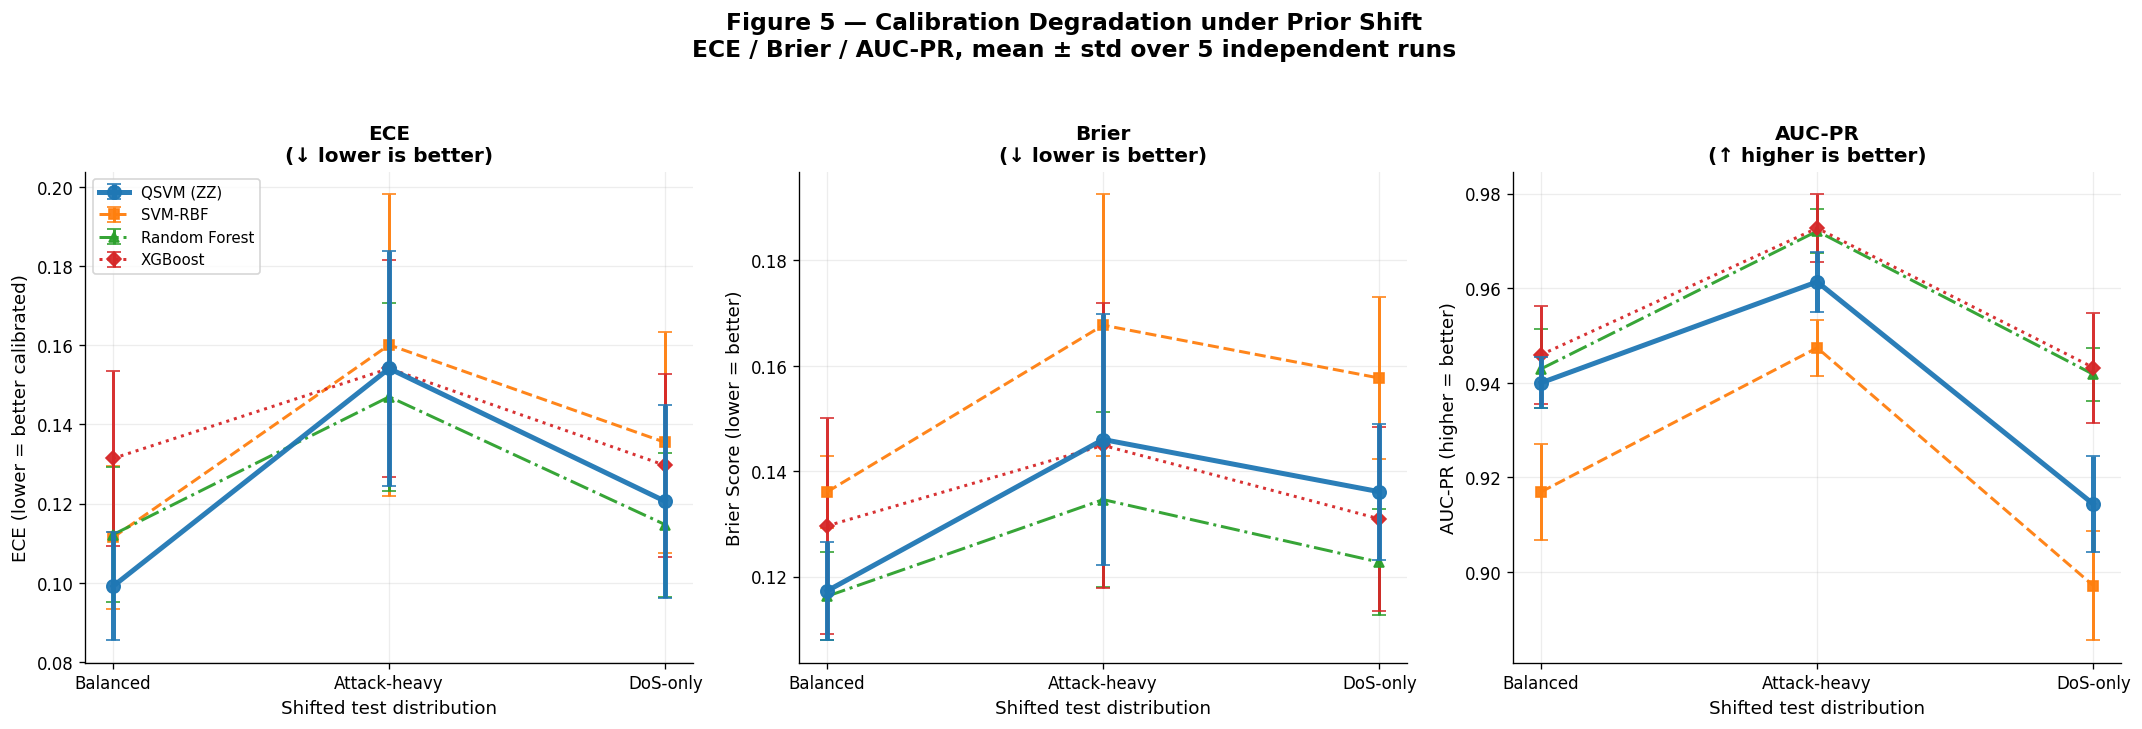

[SAVED] D:\coding\Research\Quantum\SVM\results\c4_paper2\figures\figure5_calibration_degradation_prior_shift.png


In [43]:
plt.rcParams.update({
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titleweight': 'bold', 'axes.labelsize': 11,
    'axes.grid': True, 'grid.alpha': 0.22, 'grid.linewidth': 0.8,
    'figure.dpi': 120, 'font.size': 10, 'legend.frameon': True,
})

metrics_config = [
    ('ece',    'ECE',        True,  'ECE (lower = better calibrated)'),
    ('brier',  'Brier',      True,  'Brier Score (lower = better)'),
    ('auc_pr', 'AUC-PR',     False, 'AUC-PR (higher = better)'),
]

fig5, axes = plt.subplots(1, 3, figsize=(18, 5.8), sharey=False)
fig5.suptitle(
    'Figure 5 — Calibration Degradation under Prior Shift\n'
    f'ECE / Brier / AUC-PR, mean \u00b1 std over {len(RUN_IDS)} independent runs',
    fontsize=14, fontweight='bold', y=1.04,
)

x_ticks = np.arange(len(DIST_ORDER))

for ax, (metric, short_label, lower_better, ylabel) in zip(axes, metrics_config):
    for model in MODEL_ORDER:
        d = summary_prior_raw[summary_prior_raw['model_name'] == model].copy()
        d = d.set_index('distribution_name').reindex(DIST_ORDER).reset_index()
        means = d[f'{metric}_mean'].values
        stds  = d[f'{metric}_std'].fillna(0).values
        is_q  = model == 'QSVM (ZZ)'

        ax.errorbar(
            x_ticks, means, yerr=stds,
            label=model,
            color=PLOT_COLORS[model],
            marker=MARKERS[model],
            linestyle=LINESTYLES[model],
            linewidth=3.0 if is_q else 1.8,
            markersize=8 if is_q else 6,
            capsize=4,
            alpha=0.95,
            zorder=5 if is_q else 3,
        )

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(DIST_ORDER, fontsize=10)
    ax.set_xlabel('Shifted test distribution', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    direction = '↓ lower is better' if lower_better else '↑ higher is better'
    ax.set_title(f'{short_label}\n({direction})', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.22)
    ax.set_axisbelow(True)

axes[0].legend(frameon=True, fontsize=9, loc='best')
plt.tight_layout()

fig5_path = FIG_DIR / 'figure5_calibration_degradation_prior_shift.png'
fig5.savefig(fig5_path, dpi=220, bbox_inches='tight')
plt.show()
print(f'[SAVED] {fig5_path}')


## 11. Reliability Diagrams under Prior Shift

Pooled y_true/y_prob từ tất cả 5 runs cho stable estimates.

- **Balanced**: nên đưa vào main text (Section IV)
- **Attack-heavy, DoS-only**: Appendix

=== Reliability Diagrams — Balanced (main text) ===
[SAVED] figures/reliability_diagrams_balanced.png


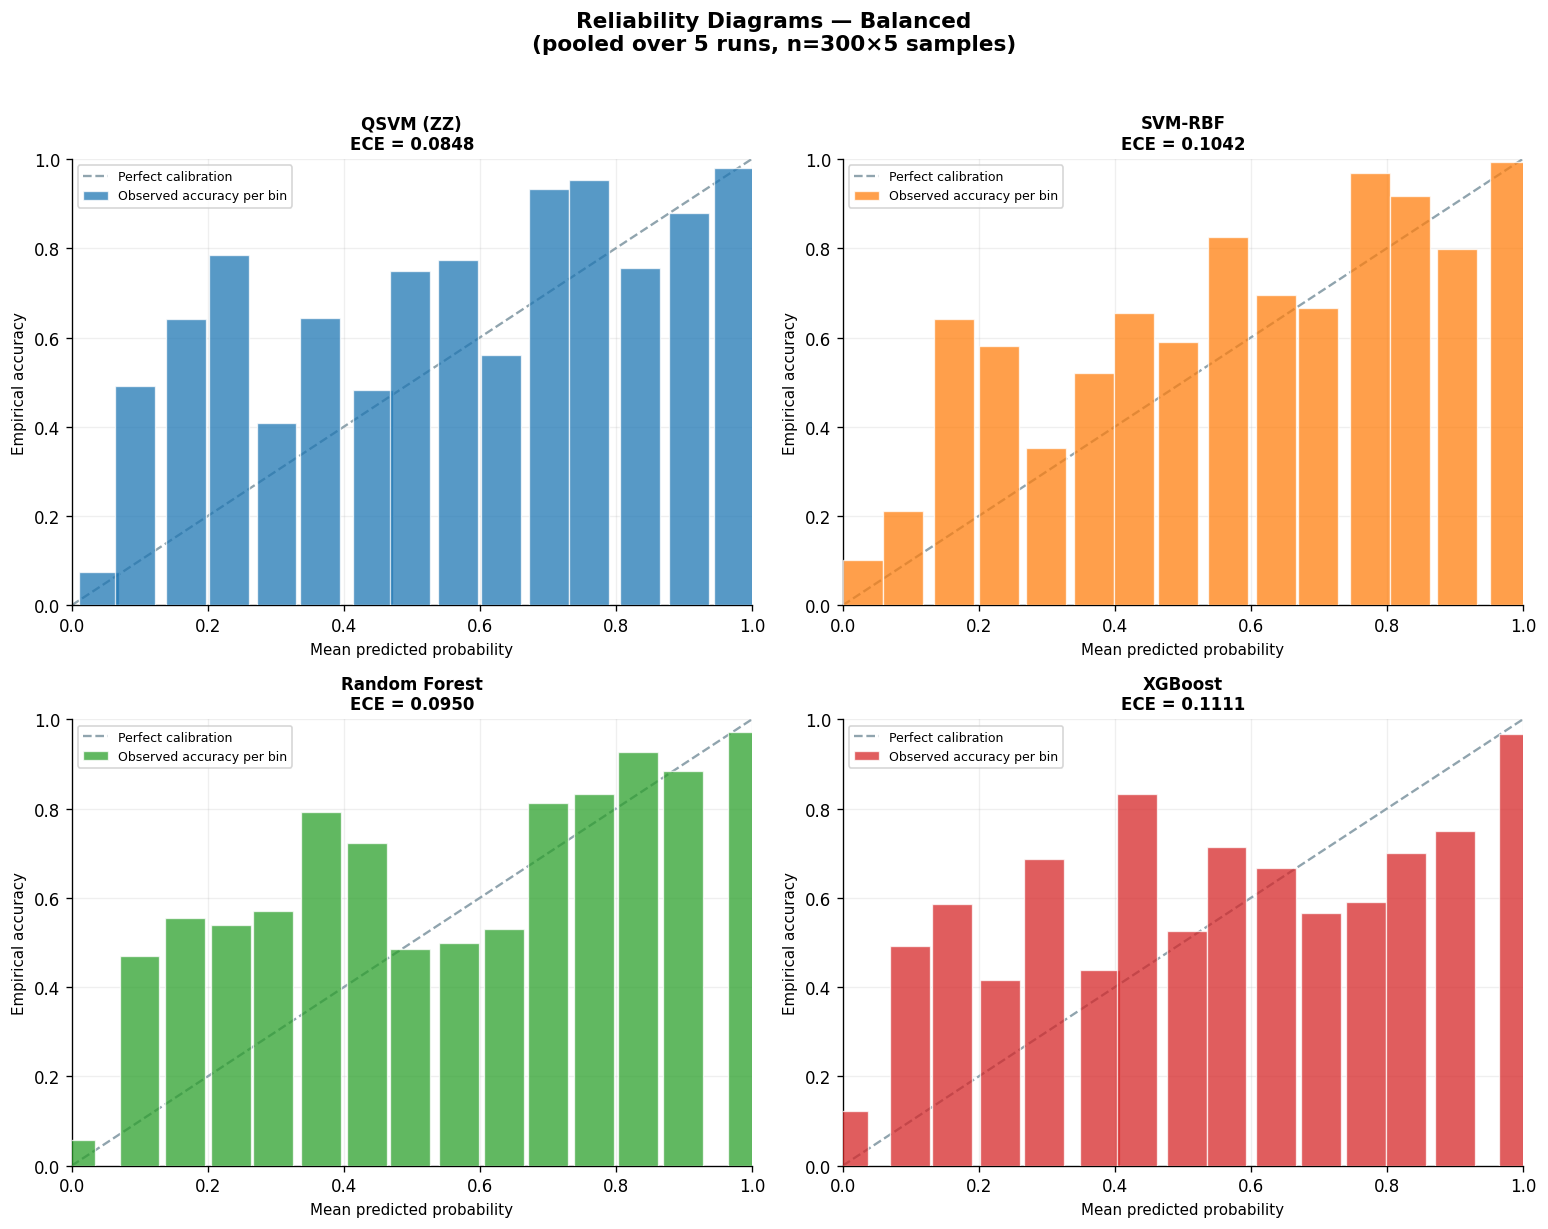

=== Reliability Diagrams — Attack-heavy (appendix) ===
[SAVED] figures/reliability_diagrams_attackheavy.png


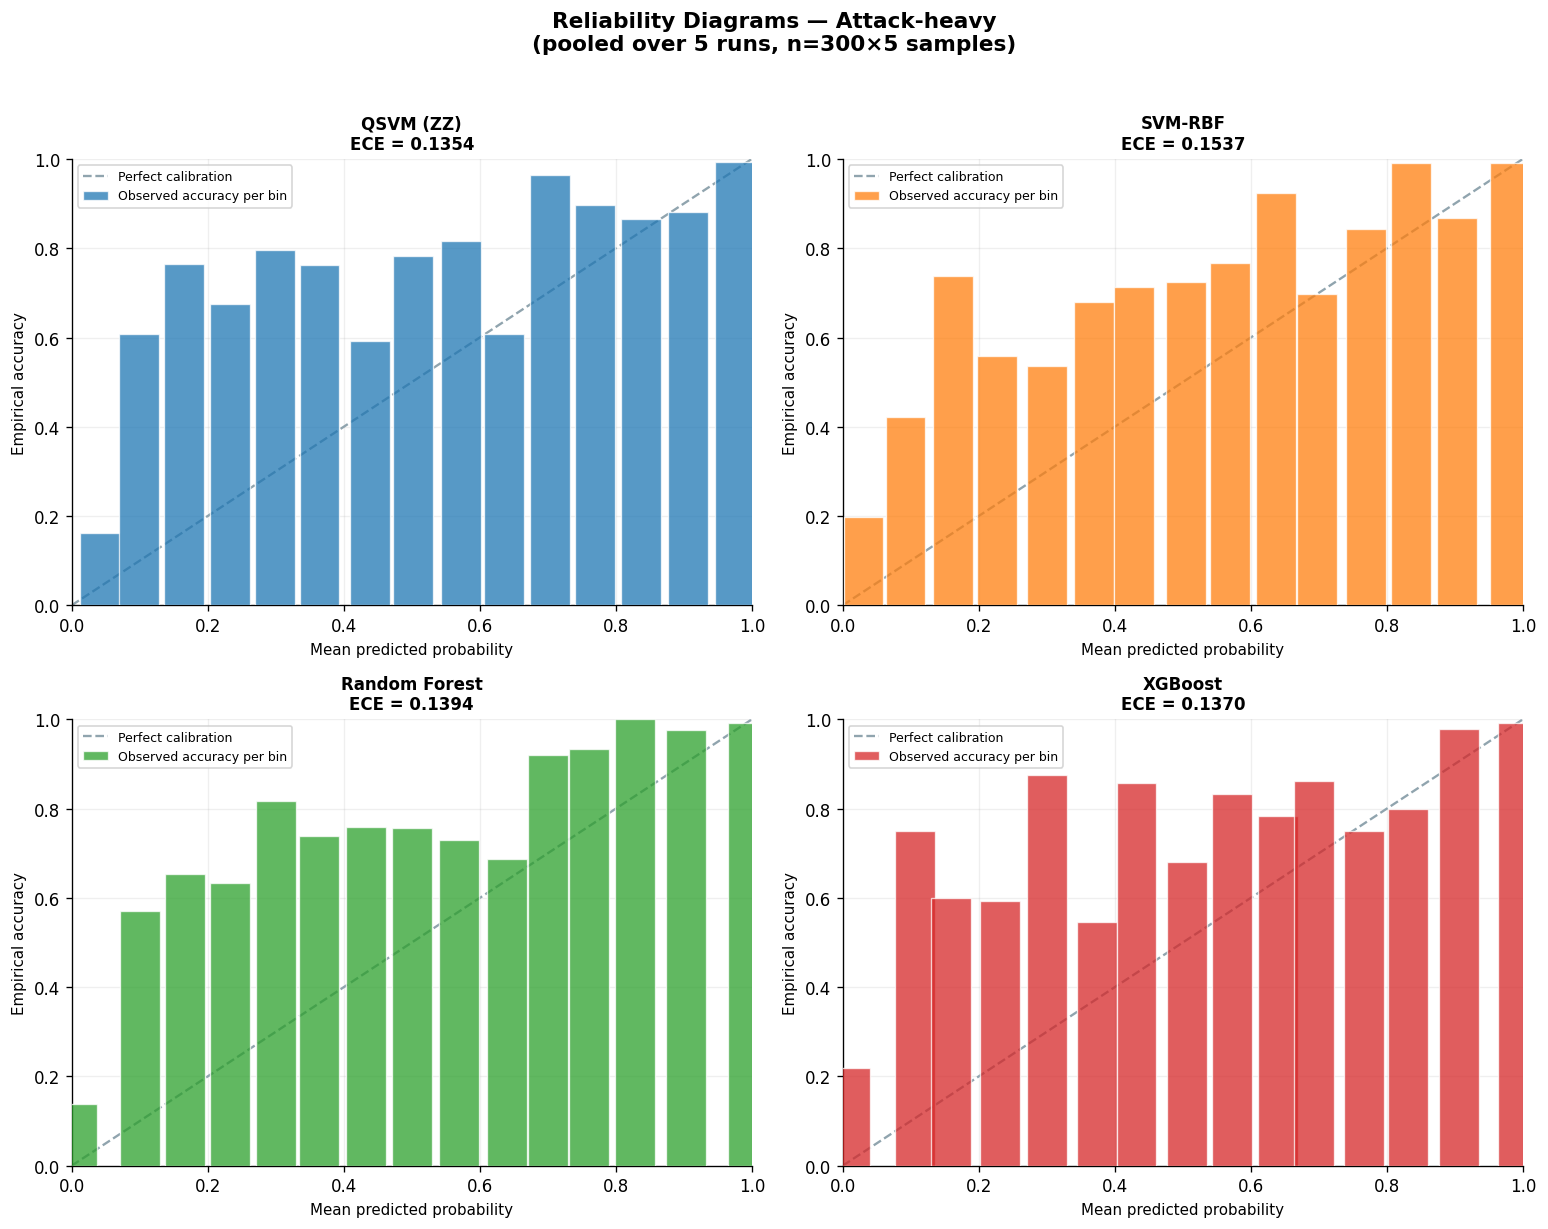

=== Reliability Diagrams — DoS-only (appendix) ===
[SAVED] figures/reliability_diagrams_dosonly.png


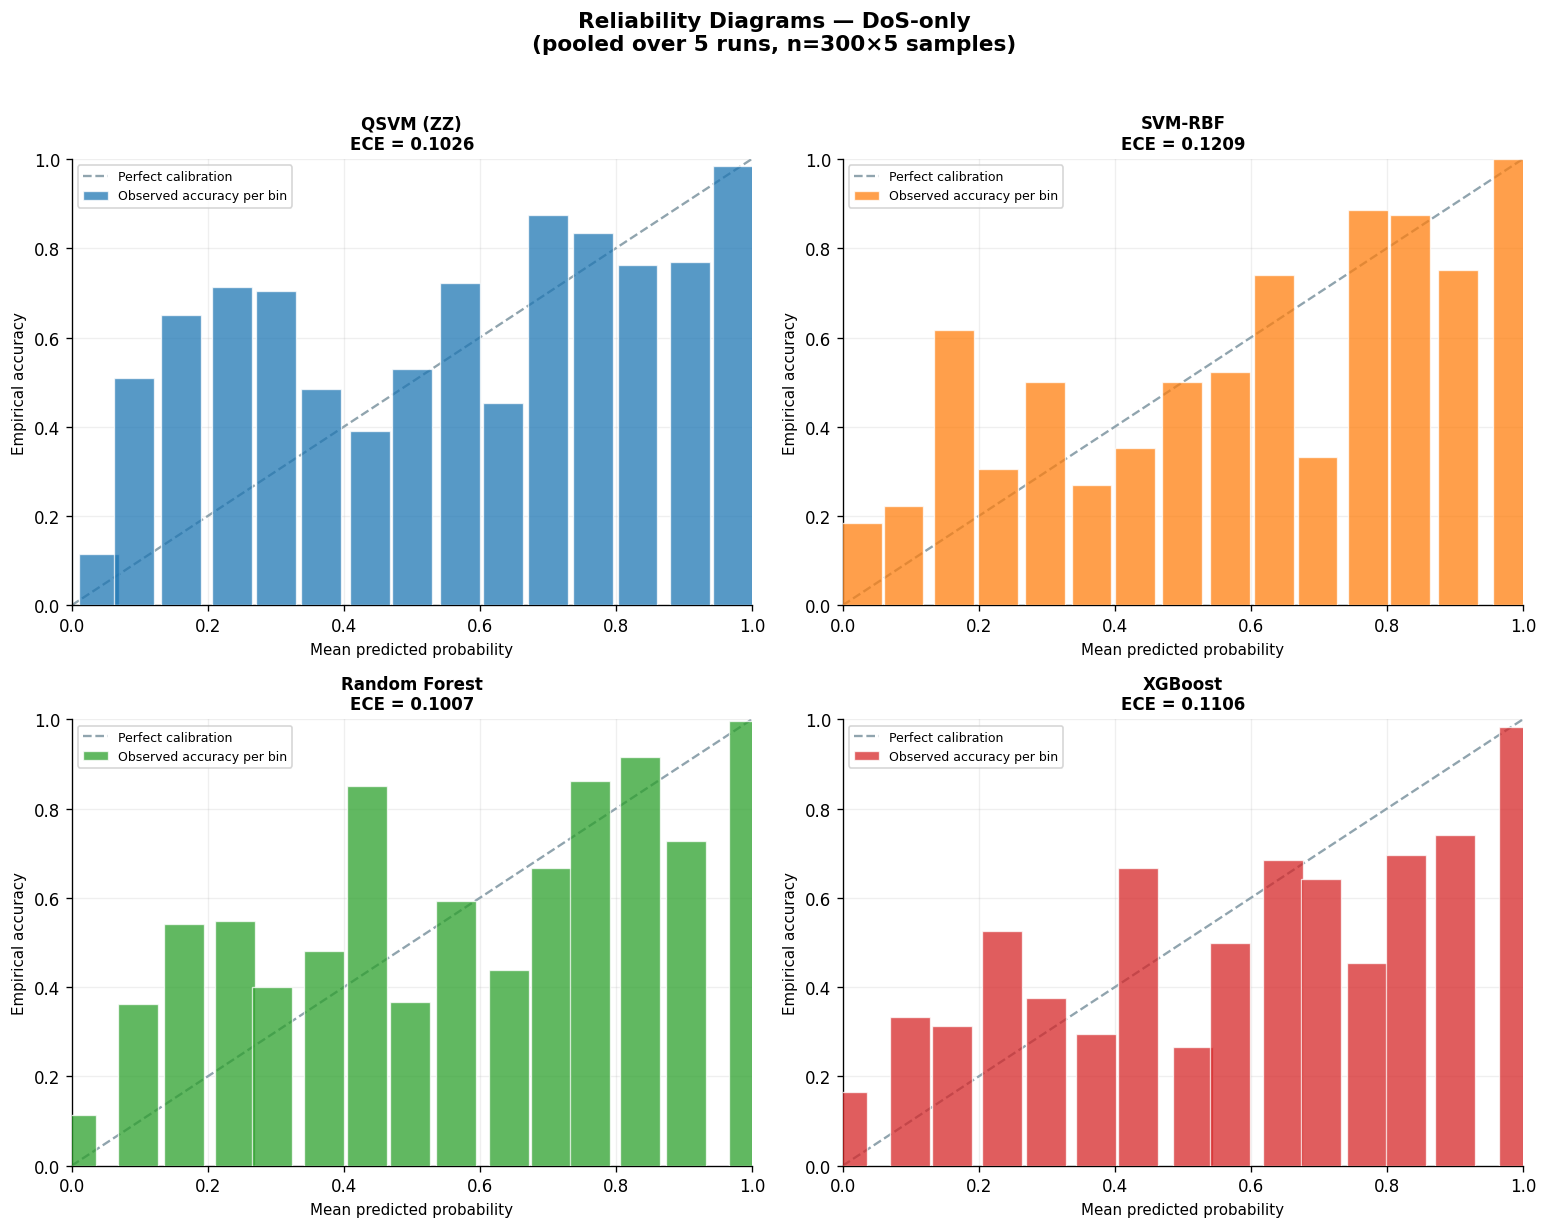

In [44]:
def plot_reliability_diagram(ax, y_true, y_prob, title='', n_bins=15, color='#4C72B0'):
    """Draw a single reliability diagram."""
    ece, bin_df = compute_ece(y_true, y_prob, n_bins=n_bins)
    valid = bin_df[bin_df['count'] > 0].copy()

    ax.plot([0, 1], [0, 1], linestyle='--', color='#90A4AE', linewidth=1.4,
            label='Perfect calibration', zorder=2)

    if not valid.empty:
        widths = np.maximum(0.04, (valid['right'] - valid['left']) * 0.88)
        ax.bar(
            valid['conf_mean'].values, valid['acc_mean'].values,
            width=widths.values,
            color=color, alpha=0.75,
            edgecolor='white', linewidth=0.8,
            label='Observed accuracy per bin',
            zorder=3,
        )

    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('Mean predicted probability', fontsize=9)
    ax.set_ylabel('Empirical accuracy', fontsize=9)
    ax.set_title(f'{title}\nECE = {ece:.4f}', fontsize=10)
    ax.grid(True, alpha=0.2)
    ax.legend(fontsize=7.5, loc='upper left')
    return ece


def plot_reliability_panel(dist_name, n_bins=15, save=True):
    """2×2 panel of reliability diagrams for one shifted distribution."""
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    axes_flat = axes.flatten()

    for ax, model_name in zip(axes_flat, MODEL_ORDER):
        y_true_chunks = [
            prior_payload[(rid, dist_name, model_name)]['y_true']
            for rid in RUN_IDS if (rid, dist_name, model_name) in prior_payload
        ]
        y_prob_chunks = [
            prior_payload[(rid, dist_name, model_name)]['y_prob']
            for rid in RUN_IDS if (rid, dist_name, model_name) in prior_payload
        ]

        if not y_true_chunks:
            ax.axis('off')
            ax.text(0.5, 0.5, f'No data\nfor {model_name}', ha='center', va='center',
                    fontsize=10, transform=ax.transAxes)
            continue

        y_true_all = np.concatenate(y_true_chunks)
        y_prob_all = np.concatenate(y_prob_chunks)
        color = PLOT_COLORS.get(model_name, '#607D8B')
        plot_reliability_diagram(ax, y_true_all, y_prob_all,
                                 title=model_name, n_bins=n_bins, color=color)

    fig.suptitle(
        f'Reliability Diagrams — {dist_name}\n'
        f'(pooled over {len(RUN_IDS)} runs, n={SHIFT_TEST_SIZE}×{len(RUN_IDS)} samples)',
        fontsize=13, fontweight='bold', y=1.02,
    )
    plt.tight_layout()
    if save:
        fname = f'reliability_diagrams_{dist_name.lower().replace("-","").replace(" ","_")}.png'
        fig.savefig(FIG_DIR / fname, dpi=220, bbox_inches='tight')
        print(f'[SAVED] figures/{fname}')
    plt.show()


print('=== Reliability Diagrams — Balanced (main text) ===')
plot_reliability_panel('Balanced', save=True)

print('=== Reliability Diagrams — Attack-heavy (appendix) ===')
plot_reliability_panel('Attack-heavy', save=True)

print('=== Reliability Diagrams — DoS-only (appendix) ===')
plot_reliability_panel('DoS-only', save=True)


## 12. Calibration Degradation Heatmap

Heatmap ECE × (model, distribution) để thấy rõ model nào bị calibration degradation nhiều nhất.

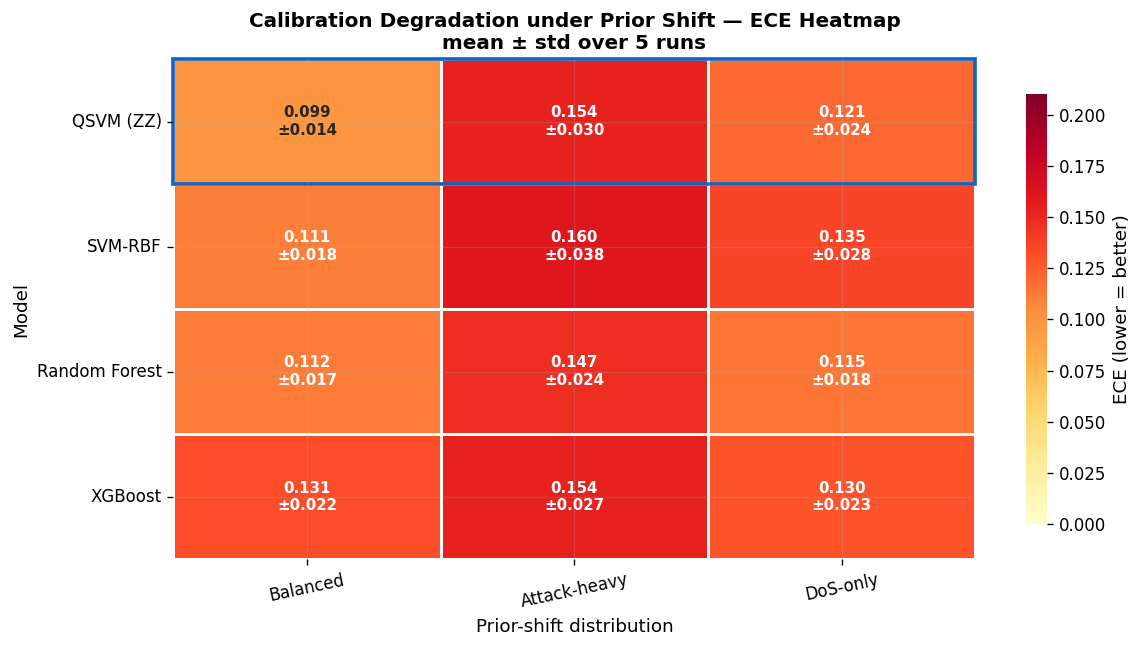

[SAVED] D:\coding\Research\Quantum\SVM\results\c4_paper2\figures\ece_heatmap_prior_shift.png


In [45]:
ece_matrix     = np.full((len(MODEL_ORDER), len(DIST_ORDER)), np.nan)
ece_std_matrix = np.full_like(ece_matrix, np.nan)
brier_matrix   = np.full_like(ece_matrix, np.nan)

for i, model in enumerate(MODEL_ORDER):
    for j, dist in enumerate(DIST_ORDER):
        row = summary_prior_raw[
            (summary_prior_raw['model_name'] == model) &
            (summary_prior_raw['distribution_name'] == dist)
        ]
        if not row.empty:
            ece_matrix[i, j]     = float(row['ece_mean'])
            ece_std_matrix[i, j] = float(row['ece_std'].fillna(0))
            brier_matrix[i, j]   = float(row['brier_mean'])

annot_ece = np.empty(ece_matrix.shape, dtype=object)
for i in range(ece_matrix.shape[0]):
    for j in range(ece_matrix.shape[1]):
        if np.isnan(ece_matrix[i, j]):
            annot_ece[i, j] = 'NA'
        else:
            annot_ece[i, j] = f'{ece_matrix[i,j]:.3f}\n\u00b1{ece_std_matrix[i,j]:.3f}'

fig_hm, ax_hm = plt.subplots(figsize=(10, 5.5))
sns.heatmap(
    ece_matrix,
    annot=annot_ece, fmt='',
    cmap='YlOrRd',
    vmin=0, vmax=min(0.5, np.nanmax(ece_matrix) + 0.05),
    linewidths=0.8, linecolor='white',
    xticklabels=DIST_ORDER,
    yticklabels=MODEL_ORDER,
    cbar_kws={'label': 'ECE (lower = better)', 'shrink': 0.86},
    annot_kws={'fontsize': 9, 'fontweight': 'bold'},
    ax=ax_hm,
)
ax_hm.set_title(
    'Calibration Degradation under Prior Shift — ECE Heatmap\n'
    f'mean \u00b1 std over {len(RUN_IDS)} runs',
    fontsize=12, fontweight='bold'
)
ax_hm.set_xlabel('Prior-shift distribution')
ax_hm.set_ylabel('Model')
ax_hm.tick_params(axis='x', rotation=12)
ax_hm.tick_params(axis='y', rotation=0)
qrow = MODEL_ORDER.index('QSVM (ZZ)')
ax_hm.add_patch(plt.Rectangle((0, qrow), len(DIST_ORDER), 1, fill=False,
                edgecolor='#1565C0', linewidth=2.2, clip_on=False))
plt.tight_layout()
hm_path = FIG_DIR / 'ece_heatmap_prior_shift.png'
plt.savefig(hm_path, dpi=180, bbox_inches='tight')
plt.show()
print(f'[SAVED] {hm_path}')


## 13. A2 — Temporal Reliability (Supplementary / Discussion)

ECE / Brier / AUC-PR trên KDDTest+ vs KDDTest-21.

Setting,Model,ECE ↓,Brier ↓,AUC-PR ↑,F1-macro
KDDTest+,QSVM (ZZ),0.1051 ± 0.0122,0.1115 ± 0.0089,0.9596 ± 0.0055,0.8511 ± 0.0152
KDDTest+,SVM-RBF,0.1192 ± 0.0236,0.1267 ± 0.0163,0.9483 ± 0.0082,0.8331 ± 0.0191
KDDTest+,Random Forest,0.1174 ± 0.0150,0.1081 ± 0.0103,0.9713 ± 0.0040,0.8446 ± 0.0165
KDDTest+,XGBoost,0.1271 ± 0.0217,0.1171 ± 0.0202,0.9717 ± 0.0075,0.8559 ± 0.0262
KDDTest-21,QSVM (ZZ),0.2671 ± 0.0396,0.2418 ± 0.0253,0.9308 ± 0.0110,0.6214 ± 0.0139
KDDTest-21,SVM-RBF,0.2773 ± 0.0480,0.2602 ± 0.0394,0.9018 ± 0.0274,0.6110 ± 0.0283
KDDTest-21,Random Forest,0.2170 ± 0.0246,0.2049 ± 0.0227,0.9429 ± 0.0068,0.6452 ± 0.0338
KDDTest-21,XGBoost,0.2190 ± 0.0379,0.2150 ± 0.0375,0.9461 ± 0.0099,0.6819 ± 0.0473


[SAVED] a2_temporal_reliability.csv


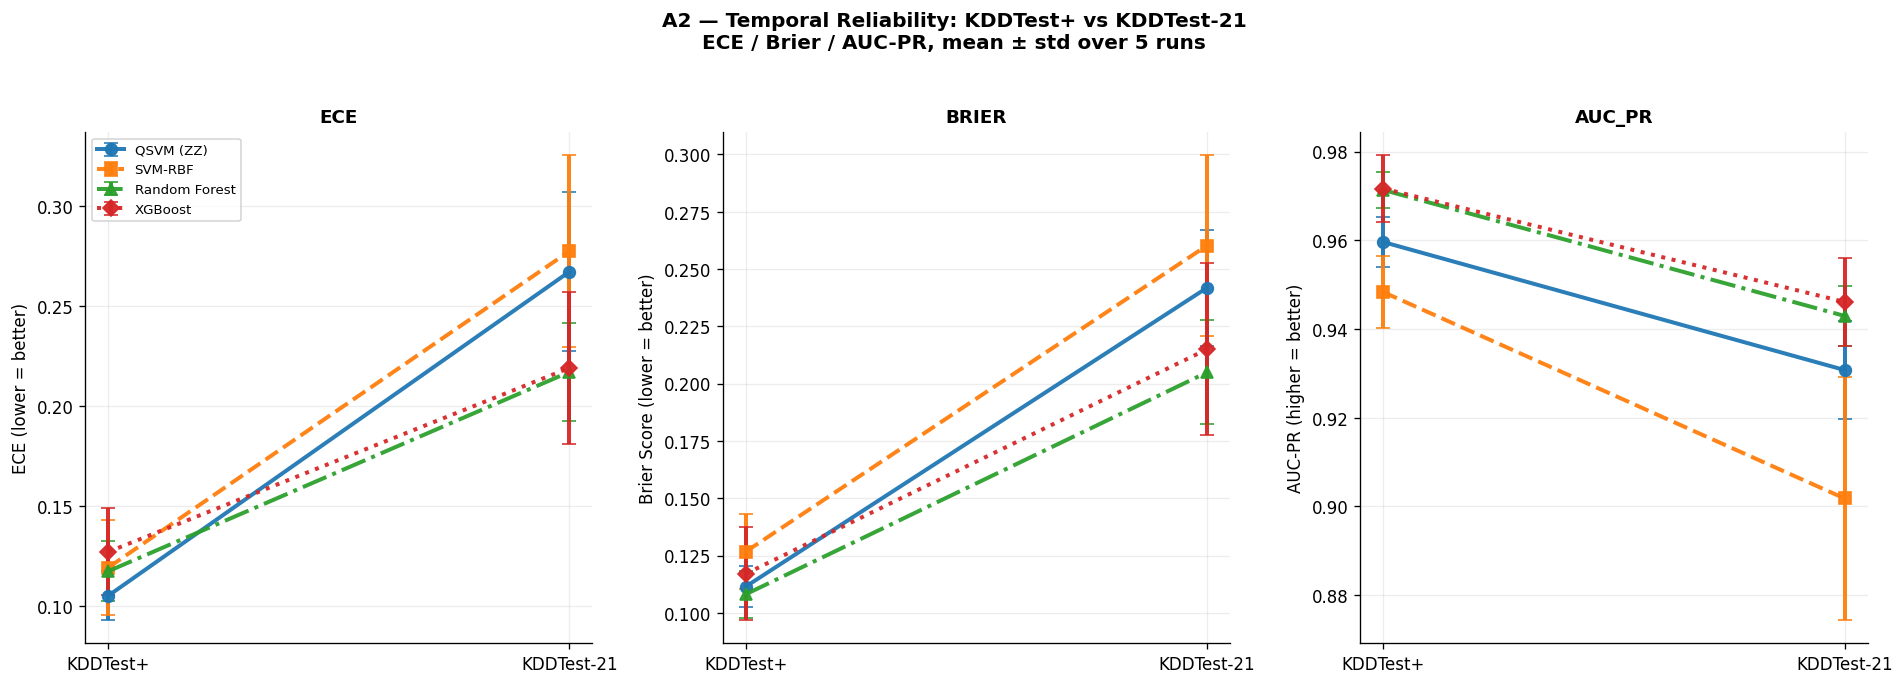

[SAVED] figures/a2_temporal_reliability.png

── ECE drop: KDDTest+ → KDDTest-21 ────────────────────────────────────────
  Model                   ECE (KDDTest+)    ECE (KDDTest-21)        ΔECE
  ----------------------------------------------------------------------
  QSVM (ZZ)           0.1051±0.0122  0.2671±0.0396  +0.1620
  SVM-RBF             0.1192±0.0236  0.2773±0.0480  +0.1581
  Random Forest       0.1174±0.0150  0.2170±0.0246  +0.0996
  XGBoost             0.1271±0.0217  0.2190±0.0379  +0.0919


In [46]:
if not temporal_df.empty:
    SETTING_ORDER = ['KDDTest+', 'KDDTest-21']

    temp_agg = (
        temporal_df.groupby(['model_name', 'distribution_name'])
        .agg(**agg_ops)
        .reset_index()
        .rename(columns={'distribution_name': 'setting_name'})
    )

    # ── Table ─────────────────────────────────────────────────────────────────
    temp_rows = []
    for setting in SETTING_ORDER:
        for model in MODEL_ORDER:
            r = temp_agg[
                (temp_agg['model_name'] == model) &
                (temp_agg['setting_name'] == setting)
            ]
            if r.empty: continue
            r = r.iloc[0]
            temp_rows.append({
                'Setting'  : setting,
                'Model'    : model,
                'ECE ↓'    : fmt(r['ece_mean'],    r['ece_std']),
                'Brier ↓'  : fmt(r['brier_mean'],  r['brier_std']),
                'AUC-PR ↑' : fmt(r['auc_pr_mean'], r['auc_pr_std']),
                'F1-macro'  : fmt(r['f1_macro_mean'], r['f1_macro_std']),
            })

    table_temporal = pd.DataFrame(temp_rows)
    display_table(table_temporal, 'A2 — Temporal Reliability: KDDTest+ vs KDDTest-21 (mean ± std)')
    table_temporal.to_csv(OUTPUT_DIR / 'a2_temporal_reliability.csv', index=False)
    print('[SAVED] a2_temporal_reliability.csv')

    # ── Figure ────────────────────────────────────────────────────────────────
    metric_map_t = [
        ('ece',    'ECE (lower = better)'),
        ('brier',  'Brier Score (lower = better)'),
        ('auc_pr', 'AUC-PR (higher = better)'),
    ]
    fig_t, axes_t = plt.subplots(1, 3, figsize=(16, 5.5), sharey=False)
    x = np.arange(len(SETTING_ORDER))

    for ax, (metric, ylabel) in zip(axes_t, metric_map_t):
        for model in MODEL_ORDER:
            d = temp_agg[temp_agg['model_name'] == model].copy()
            d = d.set_index('setting_name').reindex(SETTING_ORDER).reset_index()
            means = d[f'{metric}_mean'].values
            stds  = d[f'{metric}_std'].fillna(0).values
            ax.errorbar(
                x, means, yerr=stds,
                label=model,
                color=PLOT_COLORS[model],
                marker=MARKERS[model],
                linestyle=LINESTYLES[model],
                linewidth=2.4, markersize=7, capsize=4, alpha=0.95,
            )
        ax.set_xticks(x)
        ax.set_xticklabels(SETTING_ORDER, fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.set_title(metric.upper(), fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.22)
        ax.set_axisbelow(True)

    axes_t[0].legend(frameon=True, fontsize=8)
    fig_t.suptitle(
        'A2 — Temporal Reliability: KDDTest+ vs KDDTest-21\n'
        f'ECE / Brier / AUC-PR, mean \u00b1 std over {len(RUN_IDS)} runs',
        fontsize=12, fontweight='bold', y=1.03,
    )
    plt.tight_layout()
    fig_t.savefig(FIG_DIR / 'a2_temporal_reliability.png', dpi=220, bbox_inches='tight')
    plt.show()
    print('[SAVED] figures/a2_temporal_reliability.png')

    # ── ECE drop: KDDTest+ → KDDTest-21 ─────────────────────────────────────
    print('\n── ECE drop: KDDTest+ → KDDTest-21 ────────────────────────────────────────')
    print(f'  {"Model":18s}  {"ECE (KDDTest+)":>18s}  {"ECE (KDDTest-21)":>18s}  {"ΔECE":>10s}')
    print('  ' + '-' * 70)
    for model in MODEL_ORDER:
        std_row = temp_agg[(temp_agg['model_name']==model) & (temp_agg['setting_name']=='KDDTest+')]
        h21_row = temp_agg[(temp_agg['model_name']==model) & (temp_agg['setting_name']=='KDDTest-21')]
        if std_row.empty or h21_row.empty: continue
        ece_std = std_row.iloc[0]['ece_mean']
        ece_h21 = h21_row.iloc[0]['ece_mean']
        delta   = ece_h21 - ece_std
        print(f'  {model:18s}  {ece_std:.4f}±{std_row.iloc[0]["ece_std"]:.4f}  '
              f'{ece_h21:.4f}±{h21_row.iloc[0]["ece_std"]:.4f}  {delta:+.4f}')
else:
    print('Temporal analysis was skipped (USE_TEMPORAL_ANALYSIS=False or KDDTest-21 missing).')


## 14. Cohen's d Effect Sizes (C4-3)

QSVM vs baselines trên ECE, Brier, AUC-PR per distribution.

*Note: 5 data points per d — treat as directional indicators.*

In [47]:
baselines   = [m for m in MODEL_ORDER if m != 'QSVM (ZZ)']
effect_rows = []

for metric in ['ece', 'brier', 'auc_pr']:
    for dist in DIST_ORDER:
        sub    = prior_df[prior_df['distribution_name'] == dist]
        q_vals = sub[sub['model_name'] == 'QSVM (ZZ)'][metric].to_numpy()

        for baseline in baselines:
            b_vals = sub[sub['model_name'] == baseline][metric].to_numpy()
            d = cohens_d(q_vals, b_vals)
            # For ECE/Brier: negative d means QSVM lower (better calibrated)
            # For AUC-PR:    positive d means QSVM higher (better)
            favors_qsvm = bool(d < 0) if metric in ('ece', 'brier') else bool(d > 0)
            effect_rows.append({
                'metric'        : metric.upper(),
                'distribution'  : dist,
                'vs_baseline'   : baseline,
                "cohen's_d"     : round(d, 4) if not np.isnan(d) else np.nan,
                'interpretation': interpret_cohens_d(d),
                'favors_qsvm'   : favors_qsvm,
            })

effect_df = pd.DataFrame(effect_rows)
display_table(
    effect_df.rename(columns={"cohen's_d": "Cohen's d"}),
    "Cohen's d — QSVM vs baselines (ECE, Brier, AUC-PR per distribution)",
)
effect_df.to_csv(OUTPUT_DIR / 'cohens_d_prior_shift.csv', index=False)
print('[SAVED] cohens_d_prior_shift.csv')

# ── Cohen's d for temporal ECE (if available) ────────────────────────────────
if not temporal_df.empty:
    temp_effect_rows = []
    for baseline in baselines:
        for metric in ['ece', 'brier', 'auc_pr']:
            delta_q, delta_b = [], []
            for run_id in RUN_IDS:
                def _get(model, setting):
                    row = temporal_df[
                        (temporal_df['model_name']        == model)   &
                        (temporal_df['distribution_name'] == setting) &
                        (temporal_df['run_id']            == run_id)
                    ][metric].values
                    return float(row[0]) if len(row) else None

                q_std = _get('QSVM (ZZ)', 'KDDTest+')
                q_21  = _get('QSVM (ZZ)', 'KDDTest-21')
                b_std = _get(baseline,    'KDDTest+')
                b_21  = _get(baseline,    'KDDTest-21')

                if metric == 'auc_pr':
                    # AUC-PR: higher is better → đảo dấu để "lớn hơn = degradation lớn hơn"
                    if q_std is not None and q_21 is not None:
                        delta_q.append(q_std - q_21)
                    if b_std is not None and b_21 is not None:
                        delta_b.append(b_std - b_21)
                else:
                    # ECE, Brier: lower is better → giữ nguyên dấu
                    if q_std is not None and q_21 is not None:
                        delta_q.append(q_21 - q_std)
                    if b_std is not None and b_21 is not None:
                        delta_b.append(b_21 - b_std)

            d = cohens_d(np.array(delta_q), np.array(delta_b))
            # d < 0 → QSVM degradation ít hơn baseline (áp dụng cho cả 3 metrics)
            favors_qsvm = bool(d < 0)
            temp_effect_rows.append({
                'metric'        : metric.upper(),
                'vs_baseline'   : baseline,
                "cohen's_d"     : round(d, 4) if not np.isnan(d) else np.nan,
                'interpretation': interpret_cohens_d(d),
                'favors_qsvm'   : favors_qsvm,
                'note'          : 'Δ(KDDTest-21 − KDDTest+) per run, n=5',
            })

    temp_effect_df = pd.DataFrame(temp_effect_rows)
    display_table(
        temp_effect_df.rename(columns={"cohen's_d": "Cohen's d"}),
        "Cohen's d — Temporal degradation: QSVM vs baselines (Δ per run)",
    )
    temp_effect_df.to_csv(OUTPUT_DIR / 'cohens_d_temporal.csv', index=False)
    print('[SAVED] cohens_d_temporal.csv')
    print('\nNOTE: 5 data points per d (one Δ per run). Interpret as directional only.')


metric,distribution,vs_baseline,Cohen's d,interpretation,favors_qsvm
ECE,Balanced,SVM-RBF,-0.767900,medium,True
ECE,Balanced,Random Forest,-0.842900,large,True
ECE,Balanced,XGBoost,-1.759100,large,True
ECE,Attack-heavy,SVM-RBF,-0.174400,negligible,True
ECE,Attack-heavy,Random Forest,0.266800,small,False
ECE,Attack-heavy,XGBoost,-0.000100,negligible,True
ECE,DoS-only,SVM-RBF,-0.567100,medium,True
ECE,DoS-only,Random Forest,0.274800,small,False
ECE,DoS-only,XGBoost,-0.382000,small,True
BRIER,Balanced,SVM-RBF,-2.321000,large,True


[SAVED] cohens_d_prior_shift.csv


metric,vs_baseline,Cohen's d,interpretation,favors_qsvm,note
ECE,SVM-RBF,0.140500,negligible,False,"Δ(KDDTest-21 − KDDTest+) per run, n=5"
BRIER,SVM-RBF,-0.148600,negligible,True,"Δ(KDDTest-21 − KDDTest+) per run, n=5"
AUC_PR,SVM-RBF,-0.766100,medium,True,"Δ(KDDTest-21 − KDDTest+) per run, n=5"
ECE,Random Forest,2.894800,large,False,"Δ(KDDTest-21 − KDDTest+) per run, n=5"
BRIER,Random Forest,2.092500,large,False,"Δ(KDDTest-21 − KDDTest+) per run, n=5"
AUC_PR,Random Forest,0.047200,negligible,False,"Δ(KDDTest-21 − KDDTest+) per run, n=5"
ECE,XGBoost,3.009200,large,False,"Δ(KDDTest-21 − KDDTest+) per run, n=5"
BRIER,XGBoost,1.789400,large,False,"Δ(KDDTest-21 − KDDTest+) per run, n=5"
AUC_PR,XGBoost,0.356400,small,False,"Δ(KDDTest-21 − KDDTest+) per run, n=5"


[SAVED] cohens_d_temporal.csv

NOTE: 5 data points per d (one Δ per run). Interpret as directional only.


## 15. Export All Results

In [48]:
# Save raw data
prior_df.to_csv(OUTPUT_DIR / 'prior_shift_raw_all_runs.csv', index=False)
summary_prior_raw.to_csv(OUTPUT_DIR / 'prior_shift_summary_raw.csv', index=False)

if not temporal_df.empty:
    temporal_df.to_csv(OUTPUT_DIR / 'temporal_raw_all_runs.csv', index=False)

print('=' * 70)
print('[Paper 2 C4] All output files:')
print('=' * 70)
print('\nCSVs:')
for f in sorted(OUTPUT_DIR.glob('*.csv')):
    print(f'  {f.name}')
print('\nFigures:')
for f in sorted(FIG_DIR.glob('*.png')):
    print(f'  figures/{f.name}')
print(f'\nFIG_DIR   : {FIG_DIR}')
print(f'OUTPUT_DIR: {OUTPUT_DIR}')


[Paper 2 C4] All output files:

CSVs:
  a2_temporal_reliability.csv
  cohens_d_prior_shift.csv
  cohens_d_temporal.csv
  prior_shift_raw_all_runs.csv
  prior_shift_summary_raw.csv
  table_iv_prior_shift.csv
  temporal_raw_all_runs.csv

Figures:
  figures/a2_temporal_reliability.png
  figures/ece_heatmap_prior_shift.png
  figures/figure5_calibration_degradation_prior_shift.png
  figures/reliability_diagrams_attackheavy.png
  figures/reliability_diagrams_balanced.png
  figures/reliability_diagrams_dosonly.png

FIG_DIR   : D:\coding\Research\Quantum\SVM\results\c4_paper2\figures
OUTPUT_DIR: D:\coding\Research\Quantum\SVM\results\c4_paper2


## 16. Manuscript Notes

### Figures for the paper

| Figure | File | Section |
|---|---|---|
| Figure 5 | `figure5_calibration_degradation_prior_shift.png` | IV (main) |
| Reliability diagram — Balanced | `reliability_diagrams_balanced.png` | IV (main) |
| Reliability diagram — Attack-heavy | `reliability_diagrams_attackheavy.png` | Appendix |
| Reliability diagram — DoS-only | `reliability_diagrams_dosonly.png` | Appendix |
| ECE Heatmap | `ece_heatmap_prior_shift.png` | IV (supplementary) |
| Temporal reliability | `a2_temporal_reliability.png` | Discussion |

### Tables for the paper

| Table | File | Section |
|---|---|---|
| Table IV | `table_iv_prior_shift.csv` | IV |
| Effect sizes | `cohens_d_prior_shift.csv` | IV |
| Temporal | `a2_temporal_reliability.csv` | Discussion |

### What is excluded from this notebook (Paper 2 scope)

- E2 Gaussian perturbation experiments → Paper 1 only
- F1-only robustness narrative → use ECE / Brier / AUC-PR
- Margin stability as the primary result
- U2R/R2L class names → use **"rare attacks"** or **"minority attack group"**
- Kernel geometry / KTA / entanglement ablation

### Terminology alignment

- ✅ Use: *prior shift*, *calibration degradation*, *reliability under shift*, *rare attacks*
- ❌ Avoid: *robustness under shift* (Paper 1 term), *U2R*, *R2L*

### Expected claim (Paper 2 framing)

> "Quantum kernels provide **more reliable confidence estimates under prior shift** in several scenarios,
>  as evidenced by lower ECE and Brier scores compared to classical baselines."


# Đánh giá tổng kết kết quả C4 Paper 2

Kết quả cuối cùng của notebook C4 Paper 2 nhìn chung là **đáng tin cậy, hợp lý và khả quan** để đưa vào paper. Sau khi đã sửa lỗi syntax, kiểm soát cache và tái sinh lại các tập đánh giá, pipeline hiện tại phản ánh đúng mục tiêu của Paper 2: **đánh giá độ tin cậy (reliability), calibration, và khả năng suy giảm dưới distribution shift** thay vì chỉ nhìn vào accuracy thuần túy.

## Nhận xét chính

Thứ nhất, các kết quả trên **Balanced** cho thấy QSVM (ZZ) vẫn là một baseline rất cạnh tranh về calibration. ECE và Brier Score của QSVM ở mức thấp, trong khi AUC-PR và F1-macro vẫn duy trì tốt. Điều này cho thấy trong điều kiện phân phối thuận lợi, quantum kernel có thể tạo ra dự đoán đủ ổn định và có độ tin cậy tốt.

Thứ hai, khi chuyển sang **Attack-heavy** và **DoS-only**, mọi mô hình đều có dấu hiệu suy giảm, đúng với kỳ vọng của bài toán prior shift. QSVM không phải lúc nào cũng đứng đầu tuyệt đối ở mọi metric; một số baseline cổ điển như Random Forest hoặc XGBoost có thể nhỉnh hơn ở một vài chỉ số. Tuy nhiên, xu hướng quan trọng là QSVM vẫn giữ được mức hiệu năng và calibration cạnh tranh, nên kết quả này phù hợp để thảo luận theo hướng **“quantum kernels are competitive, but not universally dominant”**.

Thứ ba, phần **Temporal Reliability** là điểm đáng nói nhất của notebook. Khi chuyển từ **KDDTest+** sang **KDDTest-21**, ECE của QSVM tăng rõ rệt, cho thấy calibration suy giảm mạnh dưới temporal shift. Đây là một kết quả có giá trị vì nó xác nhận rằng độ tin cậy dự đoán không chỉ phụ thuộc vào tập test thông thường mà còn rất nhạy với thay đổi phân phối theo thời gian. Các baseline cổ điển cũng suy giảm, nhưng mức độ và hình thái suy giảm khác nhau, từ đó tạo ra một câu chuyện discussion tốt cho paper.

## Về Cohen’s d

Phần Cohen’s d hiện đã được diễn giải theo hướng hợp lý hơn:  
- với prior shift, effect size được tính trên dữ liệu theo từng distribution;  
- với temporal shift, effect size được tính trên **Δ per run** giữa KDDTest-21 và KDDTest+, tức là đo **mức degradation** chứ không còn pool chung hai setting.

Cách này phù hợp hơn về mặt diễn giải khoa học, vì nó trả lời trực tiếp câu hỏi: **QSVM suy giảm ít hay nhiều hơn baseline khi chuyển sang KDDTest-21?**  
Lưu ý rằng phần temporal Cohen’s d chỉ nên xem là **directional / supplementary evidence** vì số điểm dữ liệu hữu ích chỉ là 5 runs.

## Kết luận

Tổng thể, bộ kết quả này **đủ mạnh để viết Discussion**. Thông điệp hợp lý nhất là:

> QSVM cho thấy calibration và reliability tốt trong điều kiện thuận lợi, vẫn cạnh tranh dưới prior shift, nhưng calibration suy giảm rõ rệt dưới temporal shift; vì vậy quantum kernels có tiềm năng về độ tin cậy, song độ bền vững khi phân phối thay đổi vẫn là một thách thức quan trọng.

Nên tránh claim rằng QSVM vượt trội tất cả baseline trong mọi kịch bản. Cách diễn giải đúng và an toàn hơn là:
- QSVM **có chất lượng confidence tốt** trong nhiều bối cảnh,
- nhưng **không miễn nhiễm với distribution shift**,
- và các baseline classical vẫn là đối thủ mạnh ở một số metric.

